
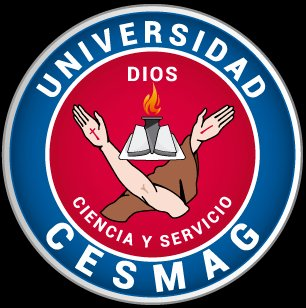

In [ ]:
#@title  Notebook 02 — Deep Learning ECG
#@markdown (portada — no modificar)
from IPython.display import display, HTML
display(HTML("""
  <!DOCTYPE html>
<html lang="es">
<head>
<meta charset="UTF-8">
<style>
  @import url('https://fonts.googleapis.com/css2?family=Crimson+Pro:ital,wght@0,300;0,400;0,600;1,300&family=JetBrains+Mono:wght@400;600&family=Barlow+Condensed:wght@300;400;700;900&display=swap');

  :root {
    --azul-cesmag: #003b7a;
    --rojo-cesmag: #c0002a;
    --dorado: #c9a84c;
    --crema: #f7f4ee;
    --gris-oscuro: #1a1a2e;
    --gris-medio: #4a4a6a;
    --blanco: #ffffff;
    --verde-ok: #2d9c5a;
    --pulso: #e8325a;
  }

  * { margin: 0; padding: 0; box-sizing: border-box; }

  body {
    font-family: 'Barlow Condensed', sans-serif;
    background: transparent;
  }

  .wrapper {
    width: 100%;
    background: var(--gris-oscuro);
    border-radius: 16px;
    overflow: hidden;
    position: relative;
    box-shadow: 0 24px 80px rgba(0,0,0,0.5);
  }

  /* ── ECG animado de fondo ── */
  .ecg-bg {
    position: absolute;
    top: 0; left: 0; right: 0; bottom: 0;
    opacity: 0.04;
    pointer-events: none;
    overflow: hidden;
  }
  .ecg-bg svg { width: 200%; height: 100%; animation: scrollECG 18s linear infinite; }
  @keyframes scrollECG {
    from { transform: translateX(0); }
    to   { transform: translateX(-50%); }
  }

  /* ── HEADER ── */
  .header {
    background: linear-gradient(135deg, var(--azul-cesmag) 0%, #001f4d 60%, #0a0a2a 100%);
    padding: 36px 48px 28px;
    display: grid;
    grid-template-columns: 110px 1fr;
    gap: 32px;
    align-items: center;
    position: relative;
    border-bottom: 3px solid var(--dorado);
  }

  .header::after {
    content: '';
    position: absolute;
    bottom: -3px; left: 0; right: 0;
    height: 1px;
    background: linear-gradient(90deg, transparent, var(--dorado), transparent);
  }

  .logo-ring {
    width: 110px; height: 110px;
    border-radius: 50%;
    padding: 4px;
    background: conic-gradient(var(--dorado), var(--rojo-cesmag), var(--dorado));
    animation: rotatering 8s linear infinite;
    flex-shrink: 0;
  }
  @keyframes rotatering {
    to { filter: hue-rotate(30deg); }
  }
  .logo-inner {
    width: 100%; height: 100%;
    border-radius: 50%;
    overflow: hidden;
    border: 3px solid var(--gris-oscuro);
  }
  .logo-inner img { width: 100%; height: 100%; object-fit: cover; }

  .univ-label {
    font-family: 'Barlow Condensed', sans-serif;
    font-weight: 300;
    font-size: 11px;
    letter-spacing: 4px;
    color: var(--dorado);
    text-transform: uppercase;
    margin-bottom: 4px;
  }
  .univ-name {
    font-family: 'Barlow Condensed', sans-serif;
    font-weight: 900;
    font-size: 28px;
    color: var(--blanco);
    letter-spacing: 1px;
    line-height: 1;
  }
  .dept {
    font-size: 13px;
    font-weight: 400;
    color: rgba(255,255,255,0.6);
    letter-spacing: 2px;
    margin-top: 6px;
  }

  .notebook-badge {
    display: inline-flex;
    align-items: center;
    gap: 8px;
    background: var(--rojo-cesmag);
    color: white;
    font-family: 'JetBrains Mono', monospace;
    font-size: 11px;
    font-weight: 600;
    padding: 5px 14px;
    border-radius: 4px;
    margin-top: 12px;
    letter-spacing: 1px;
  }
  .notebook-badge::before {
    content: '▶';
    font-size: 8px;
  }

  /* ── TÍTULO PRINCIPAL ── */
  .title-section {
    padding: 32px 48px 24px;
    background: #111128;
    position: relative;
  }
  .title-label {
    font-size: 10px;
    letter-spacing: 5px;
    color: var(--pulso);
    text-transform: uppercase;
    margin-bottom: 10px;
    font-weight: 400;
  }
  .main-title {
    font-family: 'Crimson Pro', serif;
    font-size: 34px;
    font-weight: 600;
    color: var(--blanco);
    line-height: 1.25;
    max-width: 820px;
  }
  .main-title em {
    font-style: italic;
    color: var(--dorado);
  }
  .subtitle {
    font-family: 'Barlow Condensed', sans-serif;
    font-size: 14px;
    color: rgba(255,255,255,0.45);
    margin-top: 10px;
    letter-spacing: 1px;
    font-weight: 300;
  }

  /* ── GRID DE STATS ── */
  .stats-band {
    display: grid;
    grid-template-columns: repeat(4, 1fr);
    background: #0c0c22;
    border-top: 1px solid rgba(201,168,76,0.2);
    border-bottom: 1px solid rgba(201,168,76,0.2);
  }
  .stat-box {
    padding: 18px 20px;
    text-align: center;
    border-right: 1px solid rgba(255,255,255,0.06);
    position: relative;
    transition: background 0.3s;
  }
  .stat-box:last-child { border-right: none; }
  .stat-box:hover { background: rgba(201,168,76,0.05); }
  .stat-num {
    font-family: 'JetBrains Mono', monospace;
    font-size: 28px;
    font-weight: 600;
    color: var(--dorado);
    line-height: 1;
  }
  .stat-num span { font-size: 14px; color: rgba(201,168,76,0.6); }
  .stat-desc {
    font-size: 10px;
    letter-spacing: 2px;
    color: rgba(255,255,255,0.4);
    text-transform: uppercase;
    margin-top: 5px;
  }

  /* ── CUERPO PRINCIPAL ── */
  .body-grid {
    display: grid;
    grid-template-columns: 1fr 1fr;
    gap: 0;
    background: #12122a;
  }

  .section {
    padding: 28px 32px;
    border-right: 1px solid rgba(255,255,255,0.05);
    border-bottom: 1px solid rgba(255,255,255,0.05);
  }
  .section:nth-child(even) { border-right: none; }

  .sec-title {
    font-size: 9px;
    letter-spacing: 4px;
    text-transform: uppercase;
    color: var(--pulso);
    margin-bottom: 14px;
    display: flex;
    align-items: center;
    gap: 8px;
  }
  .sec-title::after {
    content: '';
    flex: 1;
    height: 1px;
    background: rgba(232,50,90,0.3);
  }

  /* Modelos */
  .model-list { display: flex; flex-direction: column; gap: 7px; }
  .model-item {
    display: flex;
    align-items: center;
    gap: 10px;
    padding: 8px 12px;
    background: rgba(255,255,255,0.03);
    border-radius: 6px;
    border-left: 3px solid transparent;
    transition: border-color 0.2s, background 0.2s;
  }
  .model-item:hover { background: rgba(255,255,255,0.07); }
  .model-item.winner { border-left-color: var(--dorado); }
  .model-item.good   { border-left-color: var(--verde-ok); }
  .model-item.bad    { border-left-color: var(--rojo-cesmag); }
  .model-tag {
    font-family: 'JetBrains Mono', monospace;
    font-size: 11px;
    font-weight: 600;
    color: var(--blanco);
    min-width: 70px;
  }
  .model-score {
    font-family: 'JetBrains Mono', monospace;
    font-size: 11px;
    color: rgba(255,255,255,0.5);
    margin-left: auto;
  }
  .crown { font-size: 10px; }

  /* Chip-grid para arquitecturas */
  .chip-grid { display: flex; flex-wrap: wrap; gap: 6px; }
  .chip {
    font-family: 'JetBrains Mono', monospace;
    font-size: 10px;
    padding: 4px 10px;
    border-radius: 4px;
    background: rgba(0,59,122,0.4);
    border: 1px solid rgba(0,59,122,0.8);
    color: rgba(255,255,255,0.8);
    letter-spacing: 0.5px;
  }
  .chip.highlight {
    background: rgba(201,168,76,0.15);
    border-color: rgba(201,168,76,0.5);
    color: var(--dorado);
  }

  /* Métricas */
  .metric-row {
    display: flex;
    justify-content: space-between;
    align-items: center;
    padding: 7px 0;
    border-bottom: 1px solid rgba(255,255,255,0.04);
    font-size: 12px;
  }
  .metric-row:last-child { border-bottom: none; }
  .metric-name { color: rgba(255,255,255,0.5); font-weight: 300; letter-spacing: 1px; }
  .metric-val {
    font-family: 'JetBrains Mono', monospace;
    font-size: 11px;
    color: var(--blanco);
    background: rgba(255,255,255,0.06);
    padding: 2px 8px;
    border-radius: 3px;
  }

  /* Archivos */
  .file-list { display: flex; flex-direction: column; gap: 5px; }
  .file-item {
    display: flex;
    align-items: center;
    gap: 8px;
    font-family: 'JetBrains Mono', monospace;
    font-size: 10px;
    color: rgba(255,255,255,0.55);
    padding: 5px 8px;
    border-radius: 4px;
    background: rgba(255,255,255,0.02);
  }
  .file-item .ftype {
    font-size: 8px;
    padding: 1px 5px;
    border-radius: 2px;
    font-weight: 600;
    letter-spacing: 1px;
  }
  .ftype.csv   { background: rgba(45,156,90,0.3);  color: #5de89e; }
  .ftype.png   { background: rgba(201,168,76,0.3); color: var(--dorado); }
  .ftype.json  { background: rgba(0,59,122,0.5);   color: #5fa8ff; }
  .ftype.keras { background: rgba(232,50,90,0.3);  color: #ff7a9a; }

  /* ── AUTORES ── */
  .authors-bar {
    background: linear-gradient(90deg, #001530, #0a0a2a, #001530);
    padding: 20px 48px;
    display: flex;
    align-items: center;
    justify-content: space-between;
    flex-wrap: wrap;
    gap: 16px;
    border-top: 1px solid rgba(201,168,76,0.2);
  }
  .authors-group { display: flex; flex-direction: column; gap: 6px; }
  .author-label {
    font-size: 8px;
    letter-spacing: 4px;
    text-transform: uppercase;
    color: rgba(255,255,255,0.3);
  }
  .author-names { display: flex; gap: 20px; flex-wrap: wrap; }
  .author {
    font-family: 'Crimson Pro', serif;
    font-size: 16px;
    color: var(--blanco);
    font-weight: 400;
    letter-spacing: 0.5px;
  }
  .asesor-block { text-align: right; }
  .asesor-name {
    font-family: 'Crimson Pro', serif;
    font-size: 15px;
    color: var(--dorado);
    font-style: italic;
  }

  /* ── FOOTER ── */
  .footer {
    background: #0a0a18;
    padding: 12px 48px;
    display: flex;
    justify-content: space-between;
    align-items: center;
  }
  .footer-date {
    font-family: 'JetBrains Mono', monospace;
    font-size: 10px;
    color: rgba(255,255,255,0.2);
    letter-spacing: 2px;
  }
  .footer-file {
    font-family: 'JetBrains Mono', monospace;
    font-size: 10px;
    color: rgba(232,50,90,0.5);
    letter-spacing: 1px;
  }

  /* ── ECG pulse line ── */
  .pulse-line {
    width: 100%;
    height: 40px;
    background: #0a0a18;
    position: relative;
    overflow: hidden;
  }
  .pulse-line svg {
    position: absolute;
    top: 0; left: 0;
    width: 200%;
    animation: pulsemove 3s linear infinite;
  }
  @keyframes pulsemove {
    from { transform: translateX(0); }
    to   { transform: translateX(-50%); }
  }
</style>
</head>
<body>
<div class="wrapper">

  <!-- ECG fondo decorativo -->
  <div class="ecg-bg">
    <svg viewBox="0 0 1400 200" preserveAspectRatio="none" xmlns="http://www.w3.org/2000/svg">
      <polyline points="0,100 80,100 100,100 110,20 120,180 130,60 140,140 150,100 230,100 310,100 320,100 330,20 340,180 350,60 360,140 370,100 450,100 530,100 540,100 550,20 560,180 570,60 580,140 590,100 670,100 750,100 760,100 770,20 780,180 790,60 800,140 810,100 890,100 970,100 980,100 990,20 1000,180 1010,60 1020,140 1030,100 1110,100 1190,100 1200,100 1210,20 1220,180 1230,60 1240,140 1250,100 1330,100 1400,100" stroke="white" stroke-width="2" fill="none"/>
    </svg>
  </div>

  <!-- HEADER -->
  <div class="header">
    <div class="logo-ring">
      <div class="logo-inner">
        <img src="..." alt="Logo CESMAG">
      </div>
    </div>
    <div class="header-text">
      <div class="univ-label">Universidad</div>
      <div class="univ-name">CESMAG</div>
      <div class="dept">Ingeniería de Sistemas · Grupo de Investigación</div>
      <div class="notebook-badge">02_deep_learning.ipynb</div>
    </div>
  </div>

  <!-- TÍTULO -->
  <div class="title-section">
    <div class="title-label">Notebook 02 — Deep Learning · Segunda Fase Experimental</div>
    <div class="main-title">
      Predicción de Señales <em>ECG</em> con<br>Redes Neuronales Recurrentes y Convolucionales
    </div>
    <div class="subtitle">MIT-BIH Arrhythmia Database · 48 pacientes · 360 Hz · 3 pipelines óptimos heredados de NB1</div>
  </div>

  <!-- STATS -->
  <div class="stats-band">
    <div class="stat-box">
      <div class="stat-num">3<span>456</span></div>
      <div class="stat-desc">Evaluaciones DL</div>
    </div>
    <div class="stat-box">
      <div class="stat-num">4</div>
      <div class="stat-desc">Arquitecturas</div>
    </div>
    <div class="stat-box">
      <div class="stat-num">3</div>
      <div class="stat-desc">Pipelines óptimos</div>
    </div>
    <div class="stat-box">
      <div class="stat-num">2</div>
      <div class="stat-desc">Experimentos</div>
    </div>
  </div>

  <!-- BODY GRID -->
  <div class="body-grid">

    <!-- Experimento A -->
    <div class="section">
      <div class="sec-title">Experimento A · Multi-step Directo</div>
      <div class="model-list">
        <div class="model-item winner">
          <span class="crown">👑</span>
          <span class="model-tag">GRU</span>
          <span style="font-size:10px;color:rgba(255,255,255,0.4);">Recurrente</span>
          <span class="model-score">R²= 0.237</span>
        </div>
        <div class="model-item good">
          <span class="crown">·</span>
          <span class="model-tag">CNN-GRU</span>
          <span style="font-size:10px;color:rgba(255,255,255,0.4);">Híbrido</span>
          <span class="model-score">R²= 0.227</span>
        </div>
        <div class="model-item good">
          <span class="crown">·</span>
          <span class="model-tag">CNN-LSTM</span>
          <span style="font-size:10px;color:rgba(255,255,255,0.4);">Híbrido</span>
          <span class="model-score">R²= 0.227</span>
        </div>
        <div class="model-item good">
          <span class="crown">·</span>
          <span class="model-tag">LSTM</span>
          <span style="font-size:10px;color:rgba(255,255,255,0.4);">Recurrente</span>
          <span class="model-score">R²= 0.217</span>
        </div>
        <div class="model-item bad">
          <span class="crown">·</span>
          <span class="model-tag">Persistencia</span>
          <span style="font-size:10px;color:rgba(255,255,255,0.4);">Baseline</span>
          <span class="model-score">R²=−0.746</span>
        </div>
      </div>
      <div style="margin-top:12px;font-size:10px;color:rgba(255,255,255,0.3);font-family:'JetBrains Mono',monospace;">
        Horizontes: 1s · 3s · 5s &nbsp;|&nbsp; Contexto: 5 s (1 800 muestras)
      </div>
    </div>

    <!-- Experimento B -->
    <div class="section">
      <div class="sec-title">Experimento B · One-beat-ahead</div>
      <div class="model-list">
        <div class="model-item winner">
          <span class="crown">👑</span>
          <span class="model-tag">LSTM</span>
          <span style="font-size:10px;color:rgba(255,255,255,0.4);">Empate estadístico</span>
          <span class="model-score">R²= 0.659</span>
        </div>
        <div class="model-item winner">
          <span class="crown">👑</span>
          <span class="model-tag">GRU</span>
          <span style="font-size:10px;color:rgba(255,255,255,0.4);">Empate estadístico</span>
          <span class="model-score">R²= 0.659</span>
        </div>
        <div class="model-item good">
          <span class="crown">·</span>
          <span class="model-tag">CNN-LSTM</span>
          <span style="font-size:10px;color:rgba(255,255,255,0.4);">Híbrido</span>
          <span class="model-score">R²= 0.656</span>
        </div>
        <div class="model-item good">
          <span class="crown">·</span>
          <span class="model-tag">CNN-GRU</span>
          <span style="font-size:10px;color:rgba(255,255,255,0.4);">Híbrido</span>
          <span class="model-score">R²= 0.654</span>
        </div>
      </div>
      <div style="margin-top:12px;font-size:10px;color:rgba(255,255,255,0.3);font-family:'JetBrains Mono',monospace;">
        Lookback: 3 · 5 · 10 latidos &nbsp;|&nbsp; Target: 256 muestras/latido
      </div>
    </div>

    <!-- Config de entrenamiento -->
    <div class="section">
      <div class="sec-title">Configuración de Entrenamiento</div>
      <div class="chip-grid" style="margin-bottom:14px;">
        <span class="chip">LSTM</span>
        <span class="chip">GRU</span>
        <span class="chip">CNN-LSTM</span>
        <span class="chip">CNN-GRU</span>
        <span class="chip highlight">F_MED ★</span>
        <span class="chip highlight">F_N+MED ★</span>
        <span class="chip highlight">F_N+PB+MED ★</span>
      </div>
      <div class="metric-row">
        <span class="metric-name">Optimizador</span>
        <span class="metric-val">Adam</span>
      </div>
      <div class="metric-row">
        <span class="metric-name">Función de pérdida</span>
        <span class="metric-val">MSE</span>
      </div>
      <div class="metric-row">
        <span class="metric-name">Early stopping (paciencia)</span>
        <span class="metric-val">15 épocas</span>
      </div>
      <div class="metric-row">
        <span class="metric-name">Máx. épocas</span>
        <span class="metric-val">100</span>
      </div>
      <div class="metric-row">
        <span class="metric-name">Partición temporal</span>
        <span class="metric-val">80% train / 20% test</span>
      </div>
      <div class="metric-row">
        <span class="metric-name">Config. heredada → NB3</span>
        <span class="metric-val">config_NB3.json</span>
      </div>
    </div>

    <!-- Archivos generados -->
    <div class="section">
      <div class="sec-title">Archivos Generados</div>
      <div class="file-list">
        <div class="file-item"><span class="ftype csv">CSV</span>resultados_ExpA.csv · resultados_ExpB.csv</div>
        <div class="file-item"><span class="ftype csv">CSV</span>resumen, ic95, r2_train_test (×4)</div>
        <div class="file-item"><span class="ftype csv">CSV</span>wilcoxon_vs_persistencia (×2)</div>
        <div class="file-item"><span class="ftype csv">CSV</span>tabla_comparativa_NB1_NB2.csv</div>
        <div class="file-item"><span class="ftype png">PNG</span>8 visualizaciones (boxplots, predicciones)</div>
        <div class="file-item"><span class="ftype json">JSON</span>config_NB3.json (herencia → NB3)</div>
        <div class="file-item"><span class="ftype keras">KERAS</span>modelos/ (48 × 2 + global) .keras</div>
      </div>
    </div>

  </div>

  <!-- ECG PULSE LINE -->
  <div class="pulse-line">
    <svg viewBox="0 0 1400 40" preserveAspectRatio="none" xmlns="http://www.w3.org/2000/svg">
      <polyline points="0,20 100,20 120,20 130,4 140,36 148,12 156,28 164,20 264,20 364,20 374,20 384,4 394,36 402,12 410,28 418,20 518,20 618,20 628,20 638,4 648,36 656,12 664,28 672,20 772,20 872,20 882,20 892,4 902,36 910,12 918,28 926,20 1026,20 1126,20 1136,20 1146,4 1156,36 1164,12 1172,28 1180,20 1280,20 1400,20"
        stroke="#e8325a" stroke-width="1.5" fill="none" opacity="0.6"/>
    </svg>
  </div>

  <!-- AUTHORS -->
  <div class="authors-bar">
    <div class="authors-group">
      <div class="author-label">Autores</div>
      <div class="author-names">
        <span class="author">Darwin David Burbano Guerrero</span>
        <span style="color:rgba(255,255,255,0.2);align-self:center;">·</span>
        <span class="author">Darío Esteban Gómez Ordóñez</span>
      </div>
    </div>
    <div class="asesor-block">
      <div class="author-label" style="text-align:right;">Asesor</div>
      <div class="asesor-name">Mg. Héctor Andrés Mora Paz</div>
    </div>
  </div>

  <!-- FOOTER -->
  <div class="footer">
    <div class="footer-date">ANÁLISIS: 29 · MAR · 2026</div>
    <div class="footer-file">02_deep_learning.ipynb</div>
  </div>

</div>
</body>
</html>
"""))

---
## BLOQUE 1 — Instalación y configuración

In [1]:
import subprocess, sys

PAQUETES = [
    'wfdb', 'scipy', 'scikit-learn', 'statsmodels',
    'dtaidistance', 'matplotlib', 'seaborn',
    'pandas', 'numpy', 'psutil', 'tensorflow',
]
for p in PAQUETES:
    subprocess.run([sys.executable, '-m', 'pip', 'install', p, '-q'], check=False)
print('Dependencias listas.')

Dependencias listas.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os, json, time, gc
import psutil

import wfdb
from scipy import signal as spsig
from scipy.ndimage import median_filter
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

try:
    from dtaidistance import dtw as dtw_lib
    USE_DTW_LIB = True
except ImportError:
    USE_DTW_LIB = False

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers, callbacks

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})

# ── Reproducibilidad ─────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── GPU / CPU ────────────────────────────────────────────────────
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for g in gpus:
        tf.config.experimental.set_memory_growth(g, True)
    print(f'GPU detectada: {gpus[0].name}')
else:
    print('Sin GPU — usando CPU')

# ── Parámetros MIT-BIH ──────────────────────────────────────────
FS          = 360
NYQUIST     = FS / 2
PROP_TRAIN  = 0.80
F_BAJO      = 0.5
F_ALTO      = 40.0
ORDEN_BUT   = 4
FREC_NOTCH  = 60.0
Q_NOTCH     = 30.0

# ── DL Hiperparámetros ───────────────────────────────────────────
EPOCHS       = 100
PATIENCE_ES  = 15
BATCH_SIZE   = 32
LR           = 1e-3
L2_REG       = 1e-4
DROPOUT      = 0.2
SUB_W        = 30     # Sub-ventana para DL (multi-step)
BEAT_LEN     = 256
N_LOOKBACK   = 5      # Latidos de contexto
BEAT_TYPES   = set('NLRBVAFaJfEjeSe/')

# ── 48 Pacientes MIT-BIH ────────────────────────────────────────
PACIENTES = [
    '100','101','102','103','104','105','106','107','108','109',
    '111','112','113','114','115','116','117','118','119',
    '121','122','123','124',
    '200','201','202','203','205','207','208','209','210',
    '212','213','214','215','217','219','220','221','222',
    '223','228','230','231','232','233','234',
]

# ── Rutas — compatibles con Colab y local ────────────────────────
def _detectar_entorno():
    """Detecta entorno (colab/local) y resuelve la raíz del proyecto."""
    try:
        import google.colab
        from google.colab import drive
        drive.mount('/content/drive', force_remount=False)
        _drive = '/content/drive/MyDrive'
        for nombre in ['FORECASTING-ECG', 'FORECASTING ECG']:
            ruta = os.path.join(_drive, nombre)
            if os.path.isdir(ruta):
                return 'colab', ruta
        return 'colab', os.path.join(_drive, 'FORECASTING-ECG')
    except ImportError:
        ruta = os.getcwd()
        for _ in range(5):
            if os.path.isdir(os.path.join(ruta, 'data')) or os.path.isdir(os.path.join(ruta, 'datos')):
                return 'local', ruta
            ruta = os.path.dirname(ruta)
        return 'local', os.getcwd()

ENTORNO, _BASE = _detectar_entorno()

# ── Resolver rutas (soporta estructura nueva Y vieja en Drive) ───
def _resolver_ruta(base, opciones):
    """Prueba varias rutas y devuelve la primera que existe, o la primera opción."""
    for partes in opciones:
        r = os.path.join(base, *partes)
        if os.path.isdir(r):
            return r
    return os.path.join(base, *opciones[0])

RUTA_DATOS   = _resolver_ruta(_BASE, [('data', 'mit-bih'), ('datos', 'mit-bih')])
RUTA_NB1     = _resolver_ruta(_BASE, [('results', 'NB1'), ('resultados', 'exp2', 'NB1 v5 exp'), ('resultados', 'exp2', 'NB1')])
RUTA_RESULTS = _resolver_ruta(_BASE, [('results', 'NB2'), ('resultados', 'exp2', 'NB2 v3 exp'), ('resultados', 'exp2', 'NB2')])
RUTA_MODELOS = os.path.join(RUTA_RESULTS, 'modelos')

os.makedirs(RUTA_DATOS, exist_ok=True)
os.makedirs(RUTA_RESULTS, exist_ok=True)
os.makedirs(RUTA_MODELOS, exist_ok=True)

# ── Migración de checkpoint: busca con/sin prefijo exp2_ ─────────
def _buscar_checkpoint(nombre_nuevo, nombre_viejo=None):
    """Busca checkpoint con nombre nuevo; si no existe, prueba nombre viejo."""
    ruta_nueva = os.path.join(RUTA_RESULTS, nombre_nuevo)
    if os.path.exists(ruta_nueva):
        return ruta_nueva
    if nombre_viejo:
        ruta_vieja = os.path.join(RUTA_RESULTS, nombre_viejo)
        if os.path.exists(ruta_vieja):
            print(f'  [Migración] Usando checkpoint legacy: {nombre_viejo}')
            return ruta_vieja
    return ruta_nueva

def _buscar_checkpoint_in(ruta_dir, nombre_nuevo, nombre_viejo=None):
    """Busca archivo en ruta_dir con nombre nuevo; si no existe, prueba nombre viejo."""
    ruta_nueva = os.path.join(ruta_dir, nombre_nuevo)
    if os.path.exists(ruta_nueva):
        return ruta_nueva
    if nombre_viejo:
        ruta_vieja = os.path.join(ruta_dir, nombre_viejo)
        if os.path.exists(ruta_vieja):
            print(f'  [Migración] Usando archivo legacy: {nombre_viejo}')
            return ruta_vieja
    return ruta_nueva

ram = psutil.virtual_memory()
print('=' * 65)
print('  EXP1 — NB2 Deep Learning Corregido')
print('=' * 65)
print(f'  Entorno      : {ENTORNO}')
print(f'  Raíz proyecto: {_BASE}')
print(f'  Ruta NB1     : {RUTA_NB1}')
print(f'  Ruta results : {RUTA_RESULTS}')
print(f'  TF version   : {tf.__version__}')
print(f'  SEED         : {SEED}  |  Split: {int(PROP_TRAIN*100)}/{int((1-PROP_TRAIN)*100)}')
print(f'  Pacientes    : {len(PACIENTES)}')
print(f'  DL: EPOCHS={EPOCHS} BS={BATCH_SIZE} LR={LR} SUB_W={SUB_W}')
print(f'  Beats: LOOKBACK={N_LOOKBACK} BEAT_LEN={BEAT_LEN}')
print(f'  RAM disp.    : {ram.available/1e9:.1f} GB / {ram.total/1e9:.1f} GB')
print('=' * 65)

GPU detectada: /physical_device:GPU:0
Mounted at /content/drive
  EXP1 — NB2 Deep Learning Corregido
  Entorno      : colab
  Raíz proyecto: /content/drive/MyDrive/FORECASTING ECG
  Ruta NB1     : /content/drive/MyDrive/FORECASTING ECG/results/NB1
  Ruta results : /content/drive/MyDrive/FORECASTING ECG/results/NB2
  TF version   : 2.19.0
  SEED         : 42  |  Split: 80/19
  Pacientes    : 48
  DL: EPOCHS=100 BS=32 LR=0.001 SUB_W=30
  Beats: LOOKBACK=5 BEAT_LEN=256
  RAM disp.    : 11.3 GB / 13.6 GB


In [ ]:
# ══════════════════════════════════════════════════════════════════
#  ANTI-DESCONEXION COLAB 
#  Simula actividad cada 2 min para evitar timeout por inactividad.
# ══════════════════════════════════════════════════════════════════
if ENTORNO == 'colab':
    import IPython
    IPython.display.display(IPython.display.Javascript('''
        function keepAlive() {
            var sels = ["colab-connect-button",
                        "#top-toolbar > colab-connect-button",
                        "#connect"];
            for (var i = 0; i < sels.length; i++) {
                var btn = document.querySelector(sels[i]);
                if (btn) { btn.click(); break; }
            }
            console.log("Keep-alive ping: " + new Date().toLocaleTimeString());
        }
        setInterval(keepAlive, 120000);
        console.log("[OK] Anti-desconexion activo — ping cada 2 min.");
    '''))
    print('Anti-desconexion Colab activado (keep-alive cada 2 min).')
    print('Tip: NO minimices la pestana del navegador para evitar throttling de JS.')
else:
    print('Entorno local — anti-desconexion no necesario.')

<IPython.core.display.Javascript object>

Anti-desconexion Colab activado (keep-alive cada 2 min).
Tip: NO minimices la pestana del navegador para evitar throttling de JS.


---
## BLOQUE 2 — Cargar config de NB1 y datos MIT-BIH

In [4]:
# Cargar configuración de NB1 exp2
cfg_path = _buscar_checkpoint_in(RUTA_NB1, 'config_NB2.json', 'exp2_config_NB2.json')
if os.path.exists(cfg_path):
    with open(cfg_path) as f:
        CFG_NB1 = json.load(f)
    print('Config NB1 exp1 cargada:')
    print(json.dumps(CFG_NB1, indent=2, ensure_ascii=False))
    FILTROS_SEL    = CFG_NB1.get('para_NB2', {}).get('filtros_a_usar', ['F_N+PB+MED', 'F_N+MED', 'F_MED'])
    HORIZONTES_SEL = CFG_NB1.get('para_NB2', {}).get('horizontes_a_usar', [1, 3, 5])
    LOOKBACKS_SEL  = CFG_NB1.get('para_NB2', {}).get('lookbacks_a_usar', [3, 5, 10])
    BEAT_LEN       = CFG_NB1.get('para_NB2', {}).get('beat_len', BEAT_LEN)
else:
    print('[!] Config NB1 no encontrada — usando defaults alineados con NB1.')
    FILTROS_SEL    = ['F_N+PB+MED', 'F_N+MED', 'F_MED']
    HORIZONTES_SEL = [1, 3, 5]
    LOOKBACKS_SEL  = [3, 5, 10]

print(f'\nFiltros para DL : {FILTROS_SEL}')
print(f'Horizontes (s)  : {HORIZONTES_SEL}')
print(f'Lookbacks beats : {LOOKBACKS_SEL}')
print(f'Beat len        : {BEAT_LEN}')

Config NB1 exp1 cargada:
{
  "version": "2.3",
  "fecha": "2026-03-28T19:44:35.141734",
  "notebook": "NB1_Tradicionales",
  "formulacion_ExpA": {
    "tipo": "multi-step-direct (Seq-to-Seq)",
    "entrada_L_seg": 5,
    "entrada_L_muestras": 1800,
    "horizontes_seg": [
      1,
      3,
      5
    ],
    "horizontes_muestras": [
      360,
      1080,
      1800
    ],
    "nota": "Corregido de one-step-ahead (trivial) a multi-step (clínicamente útil)"
  },
  "formulacion_ExpB": {
    "tipo": "one-beat-ahead",
    "lookbacks": [
      3,
      5,
      10
    ],
    "beat_len": 256
  },
  "guardado_modelos": {
    "estrategia": "1 modelo por paciente (mejor R² entre filtros/horizontes/lookbacks)",
    "formato": "joblib LZMA-3",
    "patron_A": "ganador_A_pac{pid}_NB1.joblib",
    "patron_B": "ganador_B_pac{pid}_NB1.joblib",
    "patron_global": "ganador_ExpA_NB1.joblib / ganador_ExpB_NB1.joblib (para visualización)"
  },
  "correcciones": [
    "Formulación multi-step directo Seq-

In [5]:
# Carga MIT-BIH (idéntica a NB1)

def _descargar_si_falta(pid):
    exts = ['.dat', '.hea', '.atr']
    faltantes = [e for e in exts
                 if not os.path.exists(os.path.join(RUTA_DATOS, pid + e))]
    if not faltantes:
        return
    try:
        wfdb.dl_files('mitdb', RUTA_DATOS, [pid + e for e in faltantes])
    except Exception:
        base = 'https://physionet.org/files/mitdb/1.0.0'
        for ext in faltantes:
            os.system(f'wget -q -nc -P "{RUTA_DATOS}" {base}/{pid}{ext}')

def cargar_ecg(pid):
    _descargar_si_falta(pid)
    ruta = os.path.join(RUTA_DATOS, pid)
    try:
        rec = wfdb.rdrecord(ruta)
        ann = wfdb.rdann(ruta, 'atr')
        s   = rec.p_signal[:, 0].astype(np.float64)
        return s, ann
    except Exception as e:
        print(f'  ERROR [{pid}]: {e}')
        return None, None

REGISTROS_OK = []
print('Verificando 48 registros MIT-BIH...')
for pid in PACIENTES:
    s, _ = cargar_ecg(pid)
    if s is not None:
        REGISTROS_OK.append(pid)
    del s; gc.collect()
print(f'{len(REGISTROS_OK)}/{len(PACIENTES)} registros disponibles.')

Verificando 48 registros MIT-BIH...
48/48 registros disponibles.


---
## BLOQUE 3 — Filtros ECG

In [6]:
def f_sin(s):     return s.copy()
def f_notch(s):
    b, a = spsig.iirnotch(FREC_NOTCH, Q_NOTCH, FS)
    return spsig.filtfilt(b, a, s)
def f_butter_bp(s):
    b, a = spsig.butter(ORDEN_BUT, [F_BAJO/NYQUIST, F_ALTO/NYQUIST], btype='band')
    return spsig.filtfilt(b, a, s)
def f_mediana(s):
    k = FS // 10; k = k if k % 2 == 1 else k + 1
    return median_filter(s, size=k)
def f_fir_bp(s):
    b = spsig.firwin(101, [F_BAJO/NYQUIST, F_ALTO/NYQUIST], pass_zero=False, window='hamming')
    return spsig.filtfilt(b, [1.0], s)
def f_hp(s):
    b, a = spsig.butter(ORDEN_BUT, F_BAJO/NYQUIST, btype='high')
    return spsig.filtfilt(b, a, s)

def aplica(senal, fns):
    s = senal.copy()
    for fn in fns: s = fn(s)
    return s

FILTROS_ALL = {
    'F_SIN'       : [f_sin],
    'F_N'         : [f_notch],
    'F_PB'        : [f_butter_bp],
    'F_MED'       : [f_mediana],
    'F_FIR'       : [f_fir_bp],
    'F_PA'        : [f_hp],
    'F_N+PB'      : [f_notch, f_butter_bp],
    'F_N+MED'     : [f_notch, f_mediana],
    'F_PB+MED'    : [f_butter_bp, f_mediana],
    'F_FIR+MED'   : [f_fir_bp, f_mediana],
    'F_PA+MED'    : [f_hp, f_mediana],
    'F_N+PB+MED'  : [f_notch, f_butter_bp, f_mediana],
    'F_N+FIR+MED' : [f_notch, f_fir_bp, f_mediana],
}

FILTROS = {k: v for k, v in FILTROS_ALL.items() if k in FILTROS_SEL}
if not FILTROS:
    FILTROS = {'F_N+MED': FILTROS_ALL['F_N+MED']}

print(f'Filtros para DL: {list(FILTROS.keys())}')

Filtros para DL: ['F_MED', 'F_N+MED', 'F_N+PB+MED']


---
## BLOQUE 4 — Segmentación multi-step y latidos

In [ ]:
# ══════════════════════════════════════════════════════════════════
# Exp A: Segmentación multi-step temporal para DL
# Alineado con NB1: L = 5s fijo (1800 muestras) → H variable (1,3,5 s)
# ══════════════════════════════════════════════════════════════════

VENTANA_L      = 5                      # entrada fija: 5 s (igual que NB1)
VENTANA_L_MUES = VENTANA_L * FS         # 1800 muestras
SOLAPAMIENTO   = 0.50

def segmentar_multistep_dl(senal, tam_L, horizonte_mues, sub_w=SUB_W, solap=SOLAPAMIENTO):
    """Segmenta para DL: X = (n_sub, sub_w), y = horizonte muestras futuras.

    Igual que NB1 (segmentar_tiempo) pero reshapea X a 3D para RNN/CNN.
    L muestras de historia → H muestras de futuro.
    """
    paso = max(1, int(tam_L * (1 - solap)))
    X_list, y_list = [], []
    for i in range(0, len(senal) - tam_L - horizonte_mues, paso):
        x_flat = senal[i : i + tam_L]
        y_seg  = senal[i + tam_L : i + tam_L + horizonte_mues]
        # Reshapear entrada a (n_sub, sub_w) para secuencia temporal
        n_sub = tam_L // sub_w
        x_3d  = x_flat[:n_sub * sub_w].reshape(n_sub, sub_w)
        X_list.append(x_3d)
        y_list.append(y_seg)
    if not X_list:
        n_sub = tam_L // sub_w
        return np.empty((0, n_sub, sub_w), dtype=np.float32), \
               np.empty((0, horizonte_mues), dtype=np.float32)
    return np.array(X_list, dtype=np.float32), np.array(y_list, dtype=np.float32)


# ══════════════════════════════════════════════════════════════════
# Exp B: Segmentación por latidos
# ══════════════════════════════════════════════════════════════════

def extraer_latidos(senal_filtrada, ann, beat_len=BEAT_LEN):
    mask   = [s in BEAT_TYPES for s in ann.symbol]
    rpeaks = ann.sample[mask]
    if len(rpeaks) < 10:
        return np.empty((0, beat_len), dtype=np.float32)
    beats = []
    for i in range(1, len(rpeaks) - 1):
        start = (rpeaks[i-1] + rpeaks[i]) // 2
        end   = (rpeaks[i]   + rpeaks[i+1]) // 2
        seg   = senal_filtrada[start:end]
        if len(seg) < 50:
            continue
        beats.append(spsig.resample(seg, beat_len).astype(np.float32))
    if beats:
        return np.array(beats, dtype=np.float32)
    return np.empty((0, beat_len), dtype=np.float32)


def secuencias_latidos(beats, n_lookback=N_LOOKBACK):
    """X = (batch, n_lookback, beat_len), y = (batch, beat_len)."""
    if len(beats) <= n_lookback:
        return np.empty((0, n_lookback, BEAT_LEN), dtype=np.float32), \
               np.empty((0, BEAT_LEN), dtype=np.float32)
    X = np.array([beats[i:i+n_lookback] for i in range(len(beats) - n_lookback)])
    y = np.array([beats[i + n_lookback]  for i in range(len(beats) - n_lookback)])
    return X.astype(np.float32), y.astype(np.float32)


# ── Utilidades ───────────────────────────────────────────────────

def split_temporal(X, y, prop=PROP_TRAIN):
    n = int(len(X) * prop)
    return X[:n], y[:n], X[n:], y[n:]

def zscore_y(ytr, yte, mu, std):
    return (ytr - mu) / std, (yte - mu) / std

def zscore_3d(Xtr, Xte):
    mu  = Xtr.mean()
    std = max(Xtr.std(), 1e-8)
    return (Xtr - mu) / std, (Xte - mu) / std, mu, std

print(f'  Exp A: L={VENTANA_L}s ({VENTANA_L_MUES} mues) → H={HORIZONTES_SEL}s')
print(f'  Exp B: Lookbacks={LOOKBACKS_SEL} × {BEAT_LEN} mues → siguiente latido')
print('Funciones de segmentación DL definidas.')

  Exp A: L=5s (1800 mues) → H=[1, 3, 5]s
  Exp B: Lookbacks=[3, 5, 10] × 256 mues → siguiente latido
Funciones de segmentación DL definidas.


---
## BLOQUE 5 — Arquitecturas DL + métricas

In [8]:

# ══════════════════════════════════════════════════════════════════
# ARQUITECTURAS DEEP LEARNING — 4 modelos
# LSTM · GRU · CNN-LSTM · CNN-GRU
# ══════════════════════════════════════════════════════════════════

def build_lstm(input_shape, out_dim):
    """LSTM apilado: modela dependencias temporales largas."""
    return keras.Sequential([
        layers.Input(shape=input_shape),
        layers.LSTM(128, return_sequences=True,
                    kernel_regularizer=regularizers.l2(L2_REG)),
        layers.Dropout(DROPOUT),
        layers.LSTM(64, kernel_regularizer=regularizers.l2(L2_REG)),
        layers.Dropout(DROPOUT),
        layers.Dense(out_dim),
    ])

def build_gru(input_shape, out_dim):
    """GRU apilado: variante eficiente del LSTM."""
    return keras.Sequential([
        layers.Input(shape=input_shape),
        layers.GRU(128, return_sequences=True,
                   kernel_regularizer=regularizers.l2(L2_REG)),
        layers.Dropout(DROPOUT),
        layers.GRU(64, kernel_regularizer=regularizers.l2(L2_REG)),
        layers.Dropout(DROPOUT),
        layers.Dense(out_dim),
    ])

def build_cnn_lstm(input_shape, out_dim):
    """CNN-LSTM: CNN extrae features locales, LSTM modela secuencia."""
    return keras.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv1D(64, 3, activation='relu', padding='same',
                      kernel_regularizer=regularizers.l2(L2_REG)),
        layers.Conv1D(128, 3, activation='relu', padding='same',
                      kernel_regularizer=regularizers.l2(L2_REG)),
        layers.MaxPooling1D(2),
        layers.LSTM(64, kernel_regularizer=regularizers.l2(L2_REG)),
        layers.Dropout(DROPOUT),
        layers.Dense(out_dim),
    ])

def build_cnn_gru(input_shape, out_dim):
    """CNN-GRU: CNN extrae features locales, GRU modela secuencia."""
    return keras.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv1D(64, 3, activation='relu', padding='same',
                      kernel_regularizer=regularizers.l2(L2_REG)),
        layers.Conv1D(128, 3, activation='relu', padding='same',
                      kernel_regularizer=regularizers.l2(L2_REG)),
        layers.MaxPooling1D(2),
        layers.GRU(64, kernel_regularizer=regularizers.l2(L2_REG)),
        layers.Dropout(DROPOUT),
        layers.Dense(out_dim),
    ])

MODELOS_DL = {
    'LSTM'     : build_lstm,
    'GRU'      : build_gru,
    'CNN-LSTM' : build_cnn_lstm,
    'CNN-GRU'  : build_cnn_gru,
}

# ══════════════════════════════════════════════════════════════════
# BASELINE PERSISTENCIA — naive forecast
# ══════════════════════════════════════════════════════════════════

def persistencia_expA(Xtr_n, ytr_n, Xte_n, yte_n):
    """Exp A: repite el último valor de cada ventana X para todo el horizonte.
    Trabaja sobre datos ya normalizados (z-score)."""
    ultimo_val = Xte_n[:, -1, -1] if Xte_n.ndim == 3 else Xte_n[:, -1]
    yp = np.tile(ultimo_val[:, None], (1, yte_n.shape[1]))
    # R² train
    ultimo_tr = Xtr_n[:, -1, -1] if Xtr_n.ndim == 3 else Xtr_n[:, -1]
    yp_tr = np.tile(ultimo_tr[:, None], (1, ytr_n.shape[1]))
    r2_train = round(float(r2_score(ytr_n.flatten(), yp_tr.flatten())), 4)
    met = calcular_metricas(yte_n, yp, lat_ms=0.0)
    if met:
        met['R2_train']   = r2_train
        met['t_fit_s']    = 0.0
        met['epochs_ran'] = 0
    return met

def persistencia_expB(Xtr_n, ytr_n, Xte_n, yte_n):
    """Exp B: repite el último latido del lookback como predicción del siguiente.
    Trabaja sobre datos ya normalizados (z-score)."""
    yp = Xte_n[:, -1, :]   # último latido de cada secuencia
    # R² train
    yp_tr = Xtr_n[:, -1, :]
    r2_train = round(float(r2_score(ytr_n.flatten(), yp_tr.flatten())), 4)
    met = calcular_metricas(yte_n, yp, lat_ms=0.0)
    if met:
        met['R2_train']   = r2_train
        met['t_fit_s']    = 0.0
        met['epochs_ran'] = 0
    return met

# ── Trackers: ganador global (visualización) ─────────────────────
mejor_global_A = {'r2': -np.inf, 'model': None, 'nom': '', 'config': {},
                  'ruta': os.path.join(RUTA_MODELOS, 'ganador_A_global_NB2.keras')}
mejor_global_B = {'r2': -np.inf, 'model': None, 'nom': '', 'config': {},
                  'ruta': os.path.join(RUTA_MODELOS, 'ganador_B_global_NB2.keras')}

def actualizar_mejor_global(tracker, nom, r2_test, model_obj, config_dict):
    """Actualiza tracker global si r2_test supera el máximo."""
    if model_obj is None or not np.isfinite(r2_test):
        return
    if r2_test > tracker['r2']:
        if tracker['model'] is not None:
            del tracker['model']
            keras.backend.clear_session()
        tracker['r2']     = r2_test
        tracker['model']  = model_obj
        tracker['nom']    = nom
        tracker['config'] = config_dict.copy()
        print(f'  [★ Nuevo ganador global] {nom}  R²={r2_test:+.4f}  {config_dict}')

# ── Trackers per-paciente: 1 mejor modelo por paciente ────────────
# {pid: {'r2': float, 'model': obj|None, 'nom': str, 'config': dict}}
mejores_por_paciente_A = {}
mejores_por_paciente_B = {}

def actualizar_mejor_paciente(tracker_dict, pid, nom, r2_test, model_obj, config_dict):
    """Actualiza el mejor modelo para el paciente pid basado en R² test."""
    if model_obj is None or not np.isfinite(r2_test):
        return
    pid = str(pid)
    if pid not in tracker_dict or r2_test > tracker_dict[pid]['r2']:
        # Liberar modelo anterior del paciente
        if pid in tracker_dict and tracker_dict[pid].get('model') is not None:
            prev = tracker_dict[pid]['model']
            if prev is not model_obj:
                del prev
        tracker_dict[pid] = {
            'r2'    : r2_test,
            'model' : model_obj,
            'nom'   : nom,
            'config': config_dict.copy(),
        }

def guardar_mejor_paciente(tracker_dict, pid, prefijo, quiet=False):
    """Guarda .keras + metadata JSON del mejor modelo de un paciente.
    Libera el objeto modelo de memoria tras guardar."""
    pid = str(pid)
    if pid not in tracker_dict or tracker_dict[pid].get('model') is None:
        return
    t = tracker_dict[pid]
    ruta_mod  = os.path.join(RUTA_MODELOS, f'{prefijo}_pac{pid}_NB2.keras')
    ruta_meta = os.path.join(RUTA_MODELOS, f'{prefijo}_pac{pid}_NB2_metadata.json')
    t['model'].save(ruta_mod)
    meta = {
        'paciente'      : pid,
        'modelo'        : t['nom'],
        'r2_test'       : round(float(t['r2']), 6),
        'config'        : t['config'],
        'fecha_guardado': pd.Timestamp.now().isoformat(),
        'notebook'      : 'NB2_02_deep_learning',
    }
    with open(ruta_meta, 'w') as f:
        json.dump(meta, f, indent=2, ensure_ascii=False)
    kb = os.path.getsize(ruta_mod) / 1024
    if not quiet:
        print(f'  [pac{pid}] {t["nom"]}  R²={t["r2"]:+.4f}  ({kb:.1f} KB)')
    # Liberar modelo para no acumular RAM
    del tracker_dict[pid]['model']
    tracker_dict[pid]['model'] = None
    keras.backend.clear_session()
    gc.collect()

print(f'Modelos DL ({len(MODELOS_DL)}): {list(MODELOS_DL.keys())}')
print(f'Baseline: Persistencia (naive forecast)')
print('Guardado: 1 modelo por paciente (mejor R² entre filtros/horizontes/lookbacks)')
print('+ 1 ganador global por experimento (para visualización)')


Modelos DL (4): ['LSTM', 'GRU', 'CNN-LSTM', 'CNN-GRU']
Baseline: Persistencia (naive forecast)
Guardado: 1 modelo por paciente (mejor R² entre filtros/horizontes/lookbacks)
+ 1 ganador global por experimento (para visualización)


In [9]:
# ══════════════════════════════════════════════════════════════════
# MÉTRICAS — Con R² de TRAIN y TEST
# ══════════════════════════════════════════════════════════════════

def _dtw_manual(a, b):
    n, m = len(a), len(b)
    C = np.full((n + 1, m + 1), np.inf)
    C[0, 0] = 0.0
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            C[i, j] = (a[i-1] - b[j-1])**2 + min(C[i-1, j], C[i, j-1], C[i-1, j-1])
    return float(np.sqrt(C[n, m]))

def dtw_score(y_real, y_pred, max_seqs=50):
    """DTW promedio por secuencia individual (no sobre array aplanado).

    Calcula DTW entre cada par (y_real[i], y_pred[i]) y promedia.
    max_seqs limita la cantidad de secuencias evaluadas por velocidad.
    """
    try:
        yr = np.asarray(y_real, dtype=np.float64)
        yp = np.asarray(y_pred, dtype=np.float64)
        if yr.ndim == 1:
            yr = yr.reshape(1, -1)
            yp = yp.reshape(1, -1)
        n = min(len(yr), max_seqs)
        idx = np.random.default_rng(SEED).choice(len(yr), n, replace=False)
        dists = []
        for i in idx:
            a = yr[i]; b = yp[i]
            d = dtw_lib.distance_fast(a, b) if USE_DTW_LIB else _dtw_manual(a, b)
            if np.isfinite(d):
                dists.append(d)
        return round(float(np.mean(dists)), 4) if dists else np.nan
    except Exception:
        return np.nan

def calcular_metricas(y_real, y_pred, lat_ms):
    yr = np.asarray(y_real).flatten()
    yp = np.asarray(y_pred).flatten()
    m  = np.isfinite(yr) & np.isfinite(yp)
    if m.sum() < 5:
        return None
    yr, yp = yr[m], yp[m]
    mse = float(mean_squared_error(yr, yp))
    return {
        'R2'         : round(float(r2_score(yr, yp)), 4),
        'MSE'        : round(mse, 6),
        'RMSE'       : round(float(np.sqrt(mse)), 6),
        'MAE'        : round(float(mean_absolute_error(yr, yp)), 6),
        'DTW'        : dtw_score(y_real, y_pred),   # DTW por secuencia
        'Latencia_ms': round(float(lat_ms), 4),
    }

def entrenar_dl(nombre, build_fn, Xtr, ytr, Xte, yte):
    """Entrena modelo DL.

    Retorna (met_dict, model_obj).
    El llamador decide si conservar model_obj para el tracker o borrarlo.
    """
    input_shape = Xtr.shape[1:]
    out_dim     = ytr.shape[1] if ytr.ndim > 1 else 1
    model       = build_fn(input_shape, out_dim)

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LR),
        loss='mse',
    )

    cbs = [
        callbacks.EarlyStopping(patience=PATIENCE_ES,
                                restore_best_weights=True, monitor='val_loss'),
        callbacks.ReduceLROnPlateau(factor=0.5, patience=5, min_lr=1e-6),
    ]

    t0 = time.perf_counter()
    history = model.fit(Xtr, ytr, epochs=EPOCHS, batch_size=BATCH_SIZE,
                        validation_split=0.15, callbacks=cbs, verbose=0)
    t_fit = time.perf_counter() - t0

    # R² en TRAIN
    yp_train = model.predict(Xtr, batch_size=BATCH_SIZE, verbose=0)
    r2_train = round(float(r2_score(ytr.flatten(), yp_train.flatten())), 4)

    # R² en TEST + latencia
    t0    = time.perf_counter()
    yp_te = model.predict(Xte, batch_size=BATCH_SIZE, verbose=0)
    lat   = (time.perf_counter() - t0) / max(len(Xte), 1) * 1000

    met = calcular_metricas(yte, yp_te, lat)
    if met:
        met['R2_train']   = r2_train
        met['t_fit_s']    = round(t_fit, 3)
        met['epochs_ran'] = len(history.history.get('loss', []))

    del yp_train, yp_te; gc.collect()
    return met, model   # model_obj devuelto sin borrar

print('Función entrenar_dl definida (retorna met, model_obj).')
print('DTW corregido: promedio DTW por secuencia individual.')


Función entrenar_dl definida (retorna met, model_obj).
DTW corregido: promedio DTW por secuencia individual.


---
## BLOQUE 6 — Exp A: DL con Horizontes Temporales (multi-step)

48 pacientes × FILTROS_SEL × HORIZONTES_SEL × **5 modelos** (LSTM, GRU, CNN-LSTM, CNN-GRU, Persistencia)
L = 5s fijo → H = 1,3,5s (alineado con NB1)

**Baseline:** Persistencia (naive) como referencia mínima  
**Guardado:** 1 modelo por paciente (mejor R² de todas las combos) + 1 ganador global

In [10]:

# ══════════════════════════════════════════════════════════════════
#  EXP A — DL HORIZONTES TEMPORALES (multi-step)
#  Alineado con NB1: L=5s fijo → H=1,3,5s (HORIZONTES_SEL)
#  Guardado: 1 modelo por paciente + 1 ganador global
# ══════════════════════════════════════════════════════════════════

CKPT_A = _buscar_checkpoint('checkpoint_ExpA.csv', 'exp2_checkpoint_ExpA.csv')

filas_A, YA_A = [], set()
if os.path.exists(CKPT_A):
    _df = pd.read_csv(CKPT_A)
    filas_A = _df.to_dict('records')
    col_h = 'Horizonte_seg' if 'Horizonte_seg' in _df.columns else 'Ventana_seg'
    YA_A = set(zip(_df.Paciente.astype(str), _df.Filtro,
                   _df[col_h].astype(str), _df.Modelo))
    print(f'Checkpoint A: {len(filas_A)} filas previas.')
else:
    print('Sin checkpoint A — inicio limpio.')

# Reinicializar tracker global
mejor_global_A['r2']    = -np.inf
mejor_global_A['model'] = None
mejor_global_A['nom']   = ''

t0_total = time.perf_counter()
pid_ant, s_raw, ann_cache = None, None, None

for pid in REGISTROS_OK:
    if pid != pid_ant:
        # ── Guardar mejor modelo del paciente anterior ────────────
        if pid_ant is not None:
            guardar_mejor_paciente(mejores_por_paciente_A, pid_ant, 'ganador_A')

        if s_raw is not None: del s_raw; gc.collect()
        s_raw, ann_cache = cargar_ecg(pid)
        pid_ant = pid
        if s_raw is not None:
            print(f'\n[PAC {pid}] RAM={psutil.virtual_memory().used/1e9:.1f}GB')

    if s_raw is None: continue

    for nom_f in FILTROS_SEL:
        if nom_f not in FILTROS:
            print(f'  [!] Filtro {nom_f} no disponible, saltando.'); continue
        try:
            sf = aplica(s_raw, FILTROS[nom_f])
        except Exception:
            continue

        for hs in HORIZONTES_SEL:
            h_mues = hs * FS

            X, y = segmentar_multistep_dl(sf, VENTANA_L_MUES, h_mues)
            if len(X) < 20: continue

            Xtr, ytr, Xte, yte = split_temporal(X, y)
            del X, y; gc.collect()

            Xtr_n, Xte_n, mu, std = zscore_3d(Xtr, Xte)
            ytr_n, yte_n = zscore_y(ytr, yte, mu, std)
            del Xtr, Xte; gc.collect()

            print(f'  {nom_f:15s} H={hs}s tr={len(Xtr_n)} te={len(Xte_n)} → ',
                  end='', flush=True)

            for nom_dl, build_fn in MODELOS_DL.items():
                clave = (str(pid), nom_f, str(hs), nom_dl)
                if clave in YA_A:
                    print(f'{nom_dl}=skip ', end='', flush=True); continue

                try:
                    met, model_obj = entrenar_dl(nom_dl, build_fn,
                                                 Xtr_n, ytr_n, Xte_n, yte_n)
                except Exception as e:
                    print(f'{nom_dl}=ERR({str(e)[:20]}) ', end='', flush=True)
                    keras.backend.clear_session(); gc.collect()
                    continue

                if met is None:
                    if model_obj is not None: del model_obj
                    keras.backend.clear_session()
                    print(f'{nom_dl}=null ', end='', flush=True); continue

                filas_A.append({
                    'Paciente': pid, 'Filtro': nom_f, 'Horizonte_seg': hs,
                    'Modelo': nom_dl, 'Experimento': 'A_tiempo',
                    'n_train': len(Xtr_n), 'n_test': len(Xte_n),
                    **met,
                })
                YA_A.add(clave)
                print(f'{nom_dl}=Tr{met["R2_train"]:+.3f}/Te{met["R2"]:+.3f} ',
                      end='', flush=True)

                cfg = {'pid': pid, 'filtro': nom_f, 'horizonte_s': hs}

                # ── Tracker global ────────────────────────────────
                actualizar_mejor_global(mejor_global_A, nom_dl, met['R2'],
                                        model_obj, cfg)
                # ── Tracker per-paciente ──────────────────────────
                actualizar_mejor_paciente(mejores_por_paciente_A, pid, nom_dl,
                                          met['R2'], model_obj, cfg)

                # Liberar si no referenciado por ningún tracker
                _es_global = (model_obj is mejor_global_A['model'])
                _es_pac    = (str(pid) in mejores_por_paciente_A and
                              model_obj is mejores_por_paciente_A[str(pid)].get('model'))
                if not _es_global and not _es_pac:
                    del model_obj
                    keras.backend.clear_session()
                gc.collect()

            # ── Persistencia (baseline naive) ─────────────────────
            clave_p = (str(pid), nom_f, str(hs), 'Persistencia')
            if clave_p not in YA_A:
                met_p = persistencia_expA(Xtr_n, ytr_n, Xte_n, yte_n)
                if met_p is not None:
                    filas_A.append({
                        'Paciente': pid, 'Filtro': nom_f, 'Horizonte_seg': hs,
                        'Modelo': 'Persistencia', 'Experimento': 'A_tiempo',
                        'n_train': len(Xtr_n), 'n_test': len(Xte_n),
                        **met_p,
                    })
                    YA_A.add(clave_p)
                    print(f'Persist=Tr{met_p["R2_train"]:+.3f}/Te{met_p["R2"]:+.3f} ',
                          end='', flush=True)
            else:
                print('Persist=skip ', end='', flush=True)

            print()
            del Xtr_n, Xte_n, ytr_n, yte_n, ytr, yte; gc.collect()

        del sf; gc.collect()

    # Checkpoint cada paciente
    pd.DataFrame(filas_A).to_csv(CKPT_A, index=False)
    n_pac_g = sum(1 for f in os.listdir(RUTA_MODELOS)
                  if f.startswith('ganador_A_pac') and f.endswith('.keras'))
    print(f'  [Checkpoint: {len(filas_A)} filas | {n_pac_g} pac guardados | '
          f'mejor_A R²={mejor_global_A["r2"]:+.4f} ({mejor_global_A["nom"]})]')

if s_raw is not None: del s_raw; gc.collect()

# ── Guardar último paciente ───────────────────────────────────────
if pid_ant is not None:
    guardar_mejor_paciente(mejores_por_paciente_A, pid_ant, 'ganador_A')

# ── Guardar ganador global ────────────────────────────────────────
if mejor_global_A['model'] is not None:
    os.makedirs(RUTA_MODELOS, exist_ok=True)
    mejor_global_A['model'].save(mejor_global_A['ruta'])
    meta_g = {
        'modelo': mejor_global_A['nom'],
        'r2_test': round(float(mejor_global_A['r2']), 6),
        'config': mejor_global_A['config'],
        'fecha_guardado': pd.Timestamp.now().isoformat(),
        'notebook': 'NB2_02_deep_learning',
        'nota': 'Ganador global (1 paciente específico)',
    }
    ruta_meta_g = mejor_global_A['ruta'].replace('.keras', '_metadata.json')
    with open(ruta_meta_g, 'w') as f:
        json.dump(meta_g, f, indent=2, ensure_ascii=False)
    kb = os.path.getsize(mejor_global_A['ruta']) / 1024
    print(f'\n[ Ganador A global] {mejor_global_A["nom"]}  '
          f'R²={mejor_global_A["r2"]:+.4f}  ({kb:.0f} KB)')

df_A = pd.DataFrame(filas_A)
df_A.to_csv(os.path.join(RUTA_RESULTS, 'resultados_ExpA.csv'), index=False)

n_pac_A = sum(1 for f in os.listdir(RUTA_MODELOS)
              if f.startswith('ganador_A_pac') and f.endswith('.keras'))
t_min = (time.perf_counter() - t0_total) / 60
print(f'\n{"=" * 65}')
print(f'  EXP A COMPLETADO — {t_min:.1f} min | {len(df_A)} filas')
print(f'  Modelos por paciente: {n_pac_A}/{len(REGISTROS_OK)}')
print(f'  Ganador global: {mejor_global_A["nom"]}  R²={mejor_global_A["r2"]:+.4f}')
print('=' * 65)


Checkpoint A: 1728 filas previas.

[PAC 100] RAM=2.0GB
  F_N+MED         H=1s tr=576 te=144 → LSTM=skip GRU=skip CNN-LSTM=skip CNN-GRU=skip Persist=Tr-0.260/Te-0.071 
  F_N+MED         H=3s tr=576 te=144 → LSTM=skip GRU=skip CNN-LSTM=skip CNN-GRU=skip Persist=Tr-0.674/Te-0.553 
  F_N+MED         H=5s tr=575 te=144 → LSTM=skip GRU=skip CNN-LSTM=skip CNN-GRU=skip Persist=Tr-0.703/Te-0.638 
  F_MED           H=1s tr=576 te=144 → LSTM=skip GRU=skip CNN-LSTM=skip CNN-GRU=skip Persist=Tr-0.255/Te-0.061 
  F_MED           H=3s tr=576 te=144 → LSTM=skip GRU=skip CNN-LSTM=skip CNN-GRU=skip Persist=Tr-0.671/Te-0.550 
  F_MED           H=5s tr=575 te=144 → LSTM=skip GRU=skip CNN-LSTM=skip CNN-GRU=skip Persist=Tr-0.701/Te-0.632 
  F_N+PB+MED      H=1s tr=576 te=144 → LSTM=skip GRU=skip CNN-LSTM=skip CNN-GRU=skip Persist=Tr-0.846/Te-0.867 
  F_N+PB+MED      H=3s tr=576 te=144 → LSTM=skip GRU=skip CNN-LSTM=skip CNN-GRU=skip Persist=Tr-1.018/Te-0.812 
  F_N+PB+MED      H=5s tr=575 te=144 → LSTM=skip 

---
## BLOQUE 7 — Exp B: DL con Latidos

48 pacientes × FILTROS_SEL × LOOKBACKS_SEL × **5 modelos** (LSTM, GRU, CNN-LSTM, CNN-GRU, Persistencia)

**Baseline:** Persistencia (naive) como referencia mínima  
**Guardado:** 1 modelo por paciente (mejor R² de todas las combos) + 1 ganador global

In [11]:

# ══════════════════════════════════════════════════════════════════
#  EXP B — DL POR LATIDOS (múltiples lookbacks)
#  Alineado con NB1: itera LOOKBACKS_SEL = [3, 5, 10]
#  Guardado: 1 modelo por paciente + 1 ganador global
# ══════════════════════════════════════════════════════════════════

CKPT_B = _buscar_checkpoint('checkpoint_ExpB.csv', 'exp2_checkpoint_ExpB.csv')

filas_B, YA_B = [], set()
if os.path.exists(CKPT_B):
    _df = pd.read_csv(CKPT_B)
    filas_B = _df.to_dict('records')
    YA_B = set(zip(_df.Paciente.astype(str), _df.Filtro,
                   _df.Lookback.astype(str), _df.Modelo))
    print(f'Checkpoint B: {len(filas_B)} filas previas.')
else:
    print('Sin checkpoint B — inicio limpio.')

# Reinicializar tracker global
mejor_global_B['r2']    = -np.inf
mejor_global_B['model'] = None
mejor_global_B['nom']   = ''

t0_total = time.perf_counter()
pid_ant, s_raw, ann_cache = None, None, None

for pid in REGISTROS_OK:
    if pid != pid_ant:
        # ── Guardar mejor modelo del paciente anterior ────────────
        if pid_ant is not None:
            guardar_mejor_paciente(mejores_por_paciente_B, pid_ant, 'ganador_B')

        if s_raw is not None: del s_raw; gc.collect()
        s_raw, ann_cache = cargar_ecg(pid)
        pid_ant = pid
        if s_raw is not None:
            print(f'\n[PAC {pid}] RAM={psutil.virtual_memory().used/1e9:.1f}GB')

    if s_raw is None or ann_cache is None: continue

    for nom_f in FILTROS_SEL:
        if nom_f not in FILTROS:
            print(f'  [!] Filtro {nom_f} no disponible, saltando.'); continue
        try:
            sf = aplica(s_raw, FILTROS[nom_f])
        except Exception:
            continue

        beats = extraer_latidos(sf, ann_cache)
        del sf; gc.collect()

        for lb in LOOKBACKS_SEL:
            if len(beats) < lb + 10: continue

            X, y = secuencias_latidos(beats, n_lookback=lb)
            if len(X) < 20: continue

            Xtr, ytr, Xte, yte = split_temporal(X, y)
            del X, y; gc.collect()

            Xtr_n, Xte_n, mu, std = zscore_3d(Xtr, Xte)
            ytr_n, yte_n = zscore_y(ytr, yte, mu, std)
            del Xtr, Xte; gc.collect()

            print(f'  {nom_f:15s} LB={lb} tr={len(Xtr_n)} te={len(Xte_n)} → ',
                  end='', flush=True)

            # ── Modelos DL ────────────────────────────────────────
            for nom_dl, build_fn in MODELOS_DL.items():
                clave = (str(pid), nom_f, str(lb), nom_dl)
                if clave in YA_B:
                    print(f'{nom_dl}=skip ', end='', flush=True); continue

                try:
                    met, model_obj = entrenar_dl(nom_dl, build_fn,
                                                 Xtr_n, ytr_n, Xte_n, yte_n)
                except Exception as e:
                    print(f'{nom_dl}=ERR({str(e)[:20]}) ', end='', flush=True)
                    keras.backend.clear_session(); gc.collect()
                    continue

                if met is None:
                    if model_obj is not None: del model_obj
                    keras.backend.clear_session()
                    print(f'{nom_dl}=null ', end='', flush=True); continue

                filas_B.append({
                    'Paciente': pid, 'Filtro': nom_f, 'Lookback': lb,
                    'Modelo': nom_dl, 'Experimento': 'B_latidos',
                    'n_train': len(Xtr_n), 'n_test': len(Xte_n),
                    **met,
                })
                YA_B.add(clave)
                print(f'{nom_dl}=Tr{met["R2_train"]:+.3f}/Te{met["R2"]:+.3f} ',
                      end='', flush=True)

                cfg = {'pid': pid, 'filtro': nom_f, 'lookback': lb}

                # ── Tracker global ────────────────────────────────
                actualizar_mejor_global(mejor_global_B, nom_dl, met['R2'],
                                        model_obj, cfg)
                # ── Tracker per-paciente ──────────────────────────
                actualizar_mejor_paciente(mejores_por_paciente_B, pid, nom_dl,
                                          met['R2'], model_obj, cfg)

                # Liberar si no referenciado por ningún tracker
                _es_global = (model_obj is mejor_global_B['model'])
                _es_pac    = (str(pid) in mejores_por_paciente_B and
                              model_obj is mejores_por_paciente_B[str(pid)].get('model'))
                if not _es_global and not _es_pac:
                    del model_obj
                    keras.backend.clear_session()
                gc.collect()

            # ── Persistencia (baseline naive) ─────────────────────
            clave_p = (str(pid), nom_f, str(lb), 'Persistencia')
            if clave_p not in YA_B:
                met_p = persistencia_expB(Xtr_n, ytr_n, Xte_n, yte_n)
                if met_p is not None:
                    filas_B.append({
                        'Paciente': pid, 'Filtro': nom_f, 'Lookback': lb,
                        'Modelo': 'Persistencia', 'Experimento': 'B_latidos',
                        'n_train': len(Xtr_n), 'n_test': len(Xte_n),
                        **met_p,
                    })
                    YA_B.add(clave_p)
                    print(f'Persist=Tr{met_p["R2_train"]:+.3f}/Te{met_p["R2"]:+.3f} ',
                          end='', flush=True)
            else:
                print('Persist=skip ', end='', flush=True)

            print()
            del Xtr_n, Xte_n, ytr_n, yte_n, ytr, yte; gc.collect()

        del beats; gc.collect()

    # Checkpoint cada paciente
    pd.DataFrame(filas_B).to_csv(CKPT_B, index=False)
    n_pac_g = sum(1 for f in os.listdir(RUTA_MODELOS)
                  if f.startswith('ganador_B_pac') and f.endswith('.keras'))
    print(f'  [Checkpoint: {len(filas_B)} filas | {n_pac_g} pac guardados | '
          f'mejor_B R²={mejor_global_B["r2"]:+.4f} ({mejor_global_B["nom"]})]')

if s_raw is not None: del s_raw; gc.collect()

# ── Guardar último paciente ───────────────────────────────────────
if pid_ant is not None:
    guardar_mejor_paciente(mejores_por_paciente_B, pid_ant, 'ganador_B')

# ── Guardar ganador global ────────────────────────────────────────
if mejor_global_B['model'] is not None:
    os.makedirs(RUTA_MODELOS, exist_ok=True)
    mejor_global_B['model'].save(mejor_global_B['ruta'])
    meta_g = {
        'modelo': mejor_global_B['nom'],
        'r2_test': round(float(mejor_global_B['r2']), 6),
        'config': mejor_global_B['config'],
        'fecha_guardado': pd.Timestamp.now().isoformat(),
        'notebook': 'NB2_02_deep_learning',
        'nota': 'Ganador global (1 paciente específico)',
    }
    ruta_meta_g = mejor_global_B['ruta'].replace('.keras', '_metadata.json')
    with open(ruta_meta_g, 'w') as f:
        json.dump(meta_g, f, indent=2, ensure_ascii=False)
    kb = os.path.getsize(mejor_global_B['ruta']) / 1024
    print(f'\n[ Ganador B global] {mejor_global_B["nom"]}  '
          f'R²={mejor_global_B["r2"]:+.4f}  ({kb:.0f} KB)')

df_B = pd.DataFrame(filas_B)
df_B.to_csv(os.path.join(RUTA_RESULTS, 'resultados_ExpB.csv'), index=False)

n_pac_B = sum(1 for f in os.listdir(RUTA_MODELOS)
              if f.startswith('ganador_B_pac') and f.endswith('.keras'))
t_min = (time.perf_counter() - t0_total) / 60
print(f'\n{"=" * 65}')
print(f'  EXP B COMPLETADO — {t_min:.1f} min | {len(df_B)} filas')
print(f'  Modelos por paciente: {n_pac_B}/{len(REGISTROS_OK)}')
print(f'  Ganador global: {mejor_global_B["nom"]}  R²={mejor_global_B["r2"]:+.4f}')
print('=' * 65)


Checkpoint B: 1728 filas previas.

[PAC 100] RAM=1.8GB
  F_N+MED         LB=3 tr=1814 te=454 → LSTM=skip GRU=skip CNN-LSTM=skip CNN-GRU=skip Persist=Tr+0.490/Te+0.221 
  F_N+MED         LB=5 tr=1812 te=454 → LSTM=skip GRU=skip CNN-LSTM=skip CNN-GRU=skip Persist=Tr+0.490/Te+0.221 
  F_N+MED         LB=10 tr=1808 te=453 → LSTM=skip GRU=skip CNN-LSTM=skip CNN-GRU=skip Persist=Tr+0.490/Te+0.222 
  F_MED           LB=3 tr=1814 te=454 → LSTM=skip GRU=skip CNN-LSTM=skip CNN-GRU=skip Persist=Tr+0.488/Te+0.219 
  F_MED           LB=5 tr=1812 te=454 → LSTM=skip GRU=skip CNN-LSTM=skip CNN-GRU=skip Persist=Tr+0.487/Te+0.219 
  F_MED           LB=10 tr=1808 te=453 → LSTM=skip GRU=skip CNN-LSTM=skip CNN-GRU=skip Persist=Tr+0.487/Te+0.219 
  F_N+PB+MED      LB=3 tr=1814 te=454 → LSTM=skip GRU=skip CNN-LSTM=skip CNN-GRU=skip Persist=Tr+0.765/Te+0.303 
  F_N+PB+MED      LB=5 tr=1812 te=454 → LSTM=skip GRU=skip CNN-LSTM=skip CNN-GRU=skip Persist=Tr+0.765/Te+0.303 
  F_N+PB+MED      LB=10 tr=1808 te=453 

---
##RECONSTRUCIÓN DE MODELOS POR PACIENTE

Si los experimentos A/B terminaron (CSV completo con checkpoint) pero los modelos `.keras`  
por paciente no se guardaron (ej. sesión previa sin esta corrección), esta celda:
1. Lee `resultados_ExpA.csv` / `resultados_ExpB.csv`  
2. Identifica la mejor combinación (filtro + horizonte/lookback + modelo) por paciente  
3. Re-entrena **solo** ese modelo ganador y guarda `.keras` + metadata  

In [12]:
# ══════════════════════════════════════════════════════════════════
#  RECONSTRUCCIÓN — Re-entrenar modelos ganadores por paciente
#  Ejecutar SOLO si los CSV existen pero faltan archivos .keras
# ══════════════════════════════════════════════════════════════════

os.makedirs(RUTA_MODELOS, exist_ok=True)

def reconstruir_modelos(csv_name, exp_label, col_group, prefijo):
    """
    Lee el CSV de resultados, busca el mejor R2 por paciente,
    verifica si el .keras ya existe; si no, re-entrena y guarda.
    """
    ruta_csv = os.path.join(RUTA_RESULTS, csv_name)
    if not os.path.exists(ruta_csv):
        print(f'[{exp_label}] No existe {csv_name} — saltar.')
        return
    df = pd.read_csv(ruta_csv)
    if df.empty:
        print(f'[{exp_label}] CSV vacío — saltar.')
        return

    idx_best = df.groupby('Paciente')['R2'].idxmax()
    df_best = df.loc[idx_best].reset_index(drop=True)

    total = len(df_best)
    ya_ok, nuevos, errores = 0, 0, 0
    s_raw = None                          # ← FIX: inicializar

    for _, row in df_best.iterrows():
        pid = str(int(row.Paciente))
        ruta_modelo = os.path.join(RUTA_MODELOS, f'{prefijo}_pac{pid}_NB2.keras')

        if os.path.exists(ruta_modelo):
            ya_ok += 1
            continue

        try:
            s_raw, ann = cargar_ecg(pid)
        except Exception:
            print(f'  [!] PAC {pid}: error cargando ECG')
            errores += 1; continue
        if s_raw is None:
            errores += 1; continue

        nom_f = row.Filtro
        if nom_f not in FILTROS:
            print(f'  [!] PAC {pid}: filtro {nom_f} no disponible')
            errores += 1; continue

        try:
            sf = aplica(s_raw, FILTROS[nom_f])
        except Exception:
            errores += 1; continue

        if exp_label == 'A':
            hs = int(row.Horizonte_seg) if 'Horizonte_seg' in row.index else int(row.Ventana_seg)
            h_mues = hs * FS
            X, y = segmentar_multistep_dl(sf, VENTANA_L_MUES, h_mues)
        else:
            lb = int(row.Lookback)
            beats = extraer_latidos(sf, ann)
            if len(beats) < lb + 10:
                errores += 1; del sf; gc.collect(); continue
            X, y = secuencias_latidos(beats, n_lookback=lb)
            del beats

        del sf; gc.collect()

        if len(X) < 20:
            errores += 1; continue

        Xtr, ytr, Xte, yte = split_temporal(X, y)
        del X, y; gc.collect()
        Xtr_n, Xte_n, mu, std = zscore_3d(Xtr, Xte)
        ytr_n, yte_n = zscore_y(ytr, yte, mu, std)
        del Xtr, Xte; gc.collect()

        nom_dl = row.Modelo
        if nom_dl not in MODELOS_DL:
            print(f'  [!] PAC {pid}: modelo {nom_dl} no disponible')
            errores += 1; continue

        build_fn = MODELOS_DL[nom_dl]
        try:
            met, model_obj = entrenar_dl(nom_dl, build_fn,
                                         Xtr_n, ytr_n, Xte_n, yte_n)
        except Exception as e:
            print(f'  [!] PAC {pid} {nom_dl}: entrenamiento falló ({str(e)[:30]})')
            keras.backend.clear_session(); gc.collect()
            errores += 1; continue

        del Xtr_n, Xte_n, ytr_n, yte_n, ytr, yte; gc.collect()

        if met is None or model_obj is None:
            errores += 1; keras.backend.clear_session(); continue

        model_obj.save(ruta_modelo)

        if exp_label == 'A':
            cfg_save = {'pid': pid, 'filtro': nom_f, 'horizonte_s': hs}
        else:
            cfg_save = {'pid': pid, 'filtro': nom_f, 'lookback': lb}

        meta = {
            'modelo': nom_dl,
            'r2_test': round(float(met['R2']), 6),
            'r2_train': round(float(met['R2_train']), 6),
            'config': cfg_save,
            'fecha_guardado': pd.Timestamp.now().isoformat(),
            'notebook': 'NB2_02_deep_learning',
            'nota': f'Reconstruido desde {csv_name}',
        }
        ruta_meta = ruta_modelo.replace('.keras', '_metadata.json')
        with open(ruta_meta, 'w') as f:
            json.dump(meta, f, indent=2, ensure_ascii=False)

        del model_obj; keras.backend.clear_session(); gc.collect()
        nuevos += 1
        print(f'  [✓] PAC {pid}: {nom_dl} R²={met["R2"]:+.4f} → guardado')

    if s_raw is not None: del s_raw; gc.collect()   # ← FIX: guard
    print(f'\n[{exp_label}] Resumen: {ya_ok} ya existían | '
          f'{nuevos} reconstruidos | {errores} errores | total={total}')

# ── Ejecutar reconstrucción ───────────────────────────────────────
print('═' * 65)
print('  RECONSTRUCCIÓN DE MODELOS POR PACIENTE')
print('═' * 65)

reconstruir_modelos('resultados_ExpA.csv', 'A', 'Horizonte_seg', 'ganador_A')
print()
reconstruir_modelos('resultados_ExpB.csv', 'B', 'Lookback', 'ganador_B')

n_a = sum(1 for f in os.listdir(RUTA_MODELOS)
          if f.startswith('ganador_A_pac') and f.endswith('.keras'))
n_b = sum(1 for f in os.listdir(RUTA_MODELOS)
          if f.startswith('ganador_B_pac') and f.endswith('.keras'))
print(f'\nModelos finales: ExpA={n_a}/{len(REGISTROS_OK)}  '
      f'ExpB={n_b}/{len(REGISTROS_OK)}')

═════════════════════════════════════════════════════════════════
  RECONSTRUCCIÓN DE MODELOS POR PACIENTE
═════════════════════════════════════════════════════════════════

[A] Resumen: 48 ya existían | 0 reconstruidos | 0 errores | total=48


[B] Resumen: 48 ya existían | 0 reconstruidos | 0 errores | total=48

Modelos finales: ExpA=48/48  ExpB=48/48


---
## BLOQUE 8 — Análisis de Resultados DL

1. R² train vs test  
2. Tablas μ ± σ  
3. Wilcoxon vs Persistencia (baseline) + IC 95%  
4. Boxplots por modelo  
5. Predicción visual

In [13]:
# Cargar resultados
ruta_csv_A = os.path.join(RUTA_RESULTS, 'resultados_ExpA.csv')
ruta_csv_B = os.path.join(RUTA_RESULTS, 'resultados_ExpB.csv')

df_A = pd.read_csv(ruta_csv_A) if os.path.exists(ruta_csv_A) else pd.DataFrame()
df_B = pd.read_csv(ruta_csv_B) if os.path.exists(ruta_csv_B) else pd.DataFrame()

print(f'Exp A DL (tiempo): {len(df_A)} filas')
print(f'Exp B DL (latidos): {len(df_B)} filas')

Exp A DL (tiempo): 2160 filas
Exp B DL (latidos): 2160 filas


In [14]:
# ══════════════════════════════════════════════════════════════════
# TABLA R² TRAIN vs TEST por modelo DL
# ══════════════════════════════════════════════════════════════════

for tag, df_exp in [('Exp A — DL Horizontes', df_A),
                    ('Exp B — DL Latidos', df_B)]:
    if df_exp.empty: continue

    print(f'\n{"=" * 70}')
    print(f'  TABLA R² TRAIN vs TEST — {tag}')
    print('=' * 70)

    tabla = df_exp.groupby('Modelo').agg(
        R2_train_media = ('R2_train', 'mean'),
        R2_train_std   = ('R2_train', 'std'),
        R2_test_media  = ('R2', 'mean'),
        R2_test_std    = ('R2', 'std'),
    ).round(4).sort_values('R2_test_media', ascending=False)

    tabla['R2_train'] = tabla.apply(
        lambda r: f"{r['R2_train_media']:.4f} ± {r['R2_train_std']:.4f}", axis=1)
    tabla['R2_test'] = tabla.apply(
        lambda r: f"{r['R2_test_media']:.4f} ± {r['R2_test_std']:.4f}", axis=1)
    tabla['Diferencia'] = (tabla['R2_train_media'] - tabla['R2_test_media']).round(4)

    display(tabla[['R2_train', 'R2_test', 'Diferencia']])
    # Versión coloreada
    try:
        styled = (tabla[['R2_train_media', 'R2_test_media', 'Diferencia']]
                  .style
                  .background_gradient(subset=['R2_test_media'], cmap='RdYlGn', vmin=-0.5, vmax=1)
                  .background_gradient(subset=['Diferencia'], cmap='RdYlGn_r', vmin=0, vmax=0.3)
                  .format({'R2_train_media': '{:.4f}', 'R2_test_media': '{:.4f}', 'Diferencia': '{:.4f}'})
                  .set_caption(f'{tag} — Verde = bueno, Rojo = alerta'))
        display(styled)
    except Exception:
        pass
    tabla.to_csv(os.path.join(RUTA_RESULTS, f'r2_train_test_{tag[:5].strip()}.csv'))


  TABLA R² TRAIN vs TEST — Exp A — DL Horizontes


,R2_train,R2_test,Diferencia
Modelo,,,
GRU,0.3957 ± 0.2202,0.2371 ± 0.2322,0.1586
CNN-GRU,0.4034 ± 0.2296,0.2267 ± 0.2320,0.1767
CNN-LSTM,0.4025 ± 0.2307,0.2265 ± 0.2301,0.1760
LSTM,0.3767 ± 0.2292,0.2174 ± 0.2295,0.1593
Persistencia,-0.7034 ± 0.3501,-0.7462 ± 0.3984,0.0428


,R2_train_media,R2_test_media,Diferencia
Modelo,,,
GRU,0.3957,0.2371,0.1586
CNN-GRU,0.4034,0.2267,0.1767
CNN-LSTM,0.4025,0.2265,0.1760
LSTM,0.3767,0.2174,0.1593
Persistencia,-0.7034,-0.7462,0.0428



  TABLA R² TRAIN vs TEST — Exp B — DL Latidos


,R2_train,R2_test,Diferencia
Modelo,,,
GRU,0.7966 ± 0.1395,0.6592 ± 0.2123,0.1374
LSTM,0.7852 ± 0.1426,0.6592 ± 0.2125,0.1260
CNN-LSTM,0.7905 ± 0.1434,0.6559 ± 0.2131,0.1346
CNN-GRU,0.7953 ± 0.1458,0.6536 ± 0.2170,0.1417
Persistencia,0.1434 ± 0.5608,0.1405 ± 0.5937,0.0029


,R2_train_media,R2_test_media,Diferencia
Modelo,,,
GRU,0.7966,0.6592,0.1374
LSTM,0.7852,0.6592,0.1260
CNN-LSTM,0.7905,0.6559,0.1346
CNN-GRU,0.7953,0.6536,0.1417
Persistencia,0.1434,0.1405,0.0029


In [15]:
# ══════════════════════════════════════════════════════════════════
# RESUMEN μ ± σ POR MODELO DL
# ══════════════════════════════════════════════════════════════════

METRICAS_COLS = ['R2', 'MSE', 'RMSE', 'MAE']

for tag, df_exp in [('Exp A — DL Horizontes', df_A),
                    ('Exp B — DL Latidos', df_B)]:
    if df_exp.empty: continue

    print(f'\n{"=" * 70}')
    print(f'  RESUMEN μ ± σ POR MODELO — {tag}')
    print('=' * 70)

    resumen = []
    for modelo in df_exp['Modelo'].unique():
        sub = df_exp[df_exp['Modelo'] == modelo]
        row = {'Modelo': modelo, 'N': len(sub)}
        for col in METRICAS_COLS:
            if col in sub.columns:
                mu  = sub[col].mean()
                std = sub[col].std()
                row[f'{col}_media'] = round(mu, 4)
                row[f'{col}_std']   = round(std, 4)
                row[col] = f'{mu:.4f} ± {std:.4f}'
        resumen.append(row)

    df_resumen = pd.DataFrame(resumen).sort_values('R2_media', ascending=False)
    # Tabla coloreada
    try:
        styled = (df_resumen[['Modelo', 'N', 'R2_media', 'MSE_media', 'RMSE_media', 'MAE_media']]
                  .style
                  .background_gradient(subset=['R2_media'], cmap='RdYlGn', vmin=-0.5, vmax=1)
                  .background_gradient(subset=['MSE_media', 'RMSE_media', 'MAE_media'], cmap='RdYlGn_r')
                  .format({'R2_media': '{:.4f}', 'MSE_media': '{:.6f}', 'RMSE_media': '{:.6f}', 'MAE_media': '{:.6f}'})
                  .set_caption(f'{tag} — Resumen mu (coloreado)'))
        display(styled)
    except Exception:
        display(df_resumen[['Modelo', 'N'] + METRICAS_COLS])
    df_resumen.to_csv(os.path.join(RUTA_RESULTS, f'resumen_{tag[:5].strip()}.csv'), index=False)


  RESUMEN μ ± σ POR MODELO — Exp A — DL Horizontes


,Modelo,N,R2_media,MSE_media,RMSE_media,MAE_media
1,GRU,432,0.2371,0.848600,0.870000,0.588900
3,CNN-GRU,432,0.2267,0.856300,0.875600,0.593800
2,CNN-LSTM,432,0.2265,0.857600,0.876200,0.593000
0,LSTM,432,0.2174,0.869000,0.881700,0.596500
4,Persistencia,432,-0.7462,1.884800,1.317700,0.916400



  RESUMEN μ ± σ POR MODELO — Exp B — DL Latidos


,Modelo,N,R2_media,MSE_media,RMSE_media,MAE_media
0,LSTM,432,0.6592,0.403600,0.568900,0.335500
1,GRU,432,0.6592,0.399700,0.567600,0.336800
2,CNN-LSTM,432,0.6559,0.404800,0.570700,0.339100
3,CNN-GRU,432,0.6536,0.407200,0.572000,0.340500
4,Persistencia,432,0.1405,0.922000,0.875400,0.533100


In [16]:

# ══════════════════════════════════════════════════════════════════
# PRUEBAS ESTADÍSTICAS: Friedman · Wilcoxon vs Persistencia · IC 95%
# (Comparación rigurosa: cada modelo DL vs baseline Persistencia)
# ══════════════════════════════════════════════════════════════════
from scipy import stats

MODELOS_DL_ORDEN = ['LSTM', 'GRU', 'CNN-LSTM', 'CNN-GRU']

for tag, df_exp in [('Exp A DL', df_A), ('Exp B DL', df_B)]:
    if df_exp.empty:
        continue

    print(f'\n{"=" * 70}')
    print(f'  PRUEBAS ESTADÍSTICAS — {tag}')
    print('=' * 70)

    modelos_uniq = [m for m in MODELOS_DL_ORDEN if m in df_exp['Modelo'].unique()]
    piv = (df_exp[df_exp.Modelo.isin(modelos_uniq)]
           .pivot_table(index='Paciente', columns='Modelo', values='R2', aggfunc='mean')
           .dropna())

    # ── 1. ANOVA no paramétrica (Friedman) ────────────────────────
    if piv.shape[1] >= 3 and piv.shape[0] >= 5:
        grupos = [piv[m].values for m in piv.columns]
        stat_f, p_f = stats.friedmanchisquare(*grupos)
        print(f'\n  Friedman (ANOVA no paramétrico) sobre R² por modelo:')
        print(f'    χ² = {stat_f:.4f}   p-valor = {p_f:.6f}')
        print(f'    → {"Diferencia significativa (p<0.05)" if p_f < 0.05 else "Sin diferencia significativa (p≥0.05)"}')

    # ── 2. Wilcoxon pareados vs Persistencia (fallback: mejor DL) ─
    tiene_persist = 'Persistencia' in df_exp['Modelo'].unique()
    if tiene_persist:
        ref_nombre = 'Persistencia'
        piv_w = (df_exp[df_exp.Modelo.isin(modelos_uniq + ['Persistencia'])]
                 .pivot_table(index='Paciente', columns='Modelo', values='R2', aggfunc='mean')
                 .dropna())
    else:
        ref_nombre = piv.mean().idxmax() if not piv.empty else None
        piv_w = piv

    if ref_nombre and not piv_w.empty and ref_nombre in piv_w.columns:
        ref = piv_w[ref_nombre].values
        print(f'\n  Wilcoxon pareado — cada modelo vs {ref_nombre}:')
        filas_w = []
        for mod in piv_w.columns:
            if mod == ref_nombre:
                continue
            vals = piv_w[mod].values
            if len(vals) < 5:
                continue
            try:
                stat_w, p_w = stats.wilcoxon(vals, ref, alternative='two-sided')
                diff = np.mean(vals - ref)
                filas_w.append({
                    'Modelo': mod,
                    'ΔR²_media': round(diff, 4),
                    'W_stat': round(stat_w, 2),
                    'p_valor': round(p_w, 6),
                    'Significativo': '✓' if p_w < 0.05 else '—',
                })
            except Exception:
                pass
        if filas_w:
            df_w = pd.DataFrame(filas_w).sort_values('p_valor')
            display(df_w)
            nombre_csv = f'wilcoxon_vs_persistencia_{tag[:5].strip()}.csv'
            df_w.to_csv(os.path.join(RUTA_RESULTS, nombre_csv), index=False)

    # ── 3. Intervalos de confianza 95% ────────────────────────────
    print(f'\n  IC 95% — R² test por modelo:')
    todos_modelos_ic = modelos_uniq + (['Persistencia'] if tiene_persist else [])
    filas_ic = []
    for mod in todos_modelos_ic:
        vals = df_exp[df_exp['Modelo'] == mod]['R2'].dropna().values
        if len(vals) < 3:
            continue
        mu  = vals.mean()
        se  = vals.std(ddof=1) / np.sqrt(len(vals))
        filas_ic.append({
            'Modelo'    : mod,
            'R2_media'  : round(mu, 4),
            'IC_95_inf' : round(mu - 1.96 * se, 4),
            'IC_95_sup' : round(mu + 1.96 * se, 4),
            'n'         : len(vals),
        })
    if filas_ic:
        df_ic = pd.DataFrame(filas_ic).sort_values('R2_media', ascending=False)
        display(df_ic)
        df_ic.to_csv(os.path.join(RUTA_RESULTS,
                     f'ic95_{tag[:5].strip()}.csv'), index=False)



  PRUEBAS ESTADÍSTICAS — Exp A DL

  Friedman (ANOVA no paramétrico) sobre R² por modelo:
    χ² = 15.3750   p-valor = 0.001523
    → Diferencia significativa (p<0.05)

  Wilcoxon pareado — cada modelo vs Persistencia:


,Modelo,ΔR²_media,W_stat,p_valor,Significativo
0,CNN-GRU,0.9729,0.0,0.0,✓
1,CNN-LSTM,0.9727,0.0,0.0,✓
2,GRU,0.9833,0.0,0.0,✓
3,LSTM,0.9636,0.0,0.0,✓



  IC 95% — R² test por modelo:


,Modelo,R2_media,IC_95_inf,IC_95_sup,n
1,GRU,0.2371,0.2152,0.2590,432
3,CNN-GRU,0.2267,0.2048,0.2486,432
2,CNN-LSTM,0.2265,0.2048,0.2482,432
0,LSTM,0.2174,0.1958,0.2391,432
4,Persistencia,-0.7462,-0.7838,-0.7086,432



  PRUEBAS ESTADÍSTICAS — Exp B DL

  Friedman (ANOVA no paramétrico) sobre R² por modelo:
    χ² = 8.7000   p-valor = 0.033557
    → Diferencia significativa (p<0.05)

  Wilcoxon pareado — cada modelo vs Persistencia:


,Modelo,ΔR²_media,W_stat,p_valor,Significativo
0,CNN-GRU,0.5130,11.0,0.0,✓
1,CNN-LSTM,0.5154,16.0,0.0,✓
2,GRU,0.5187,19.0,0.0,✓
3,LSTM,0.5187,12.0,0.0,✓



  IC 95% — R² test por modelo:


,Modelo,R2_media,IC_95_inf,IC_95_sup,n
0,LSTM,0.6592,0.6392,0.6792,432
1,GRU,0.6592,0.6392,0.6792,432
2,CNN-LSTM,0.6559,0.6358,0.6760,432
3,CNN-GRU,0.6536,0.6331,0.6740,432
4,Persistencia,0.1405,0.0845,0.1965,432


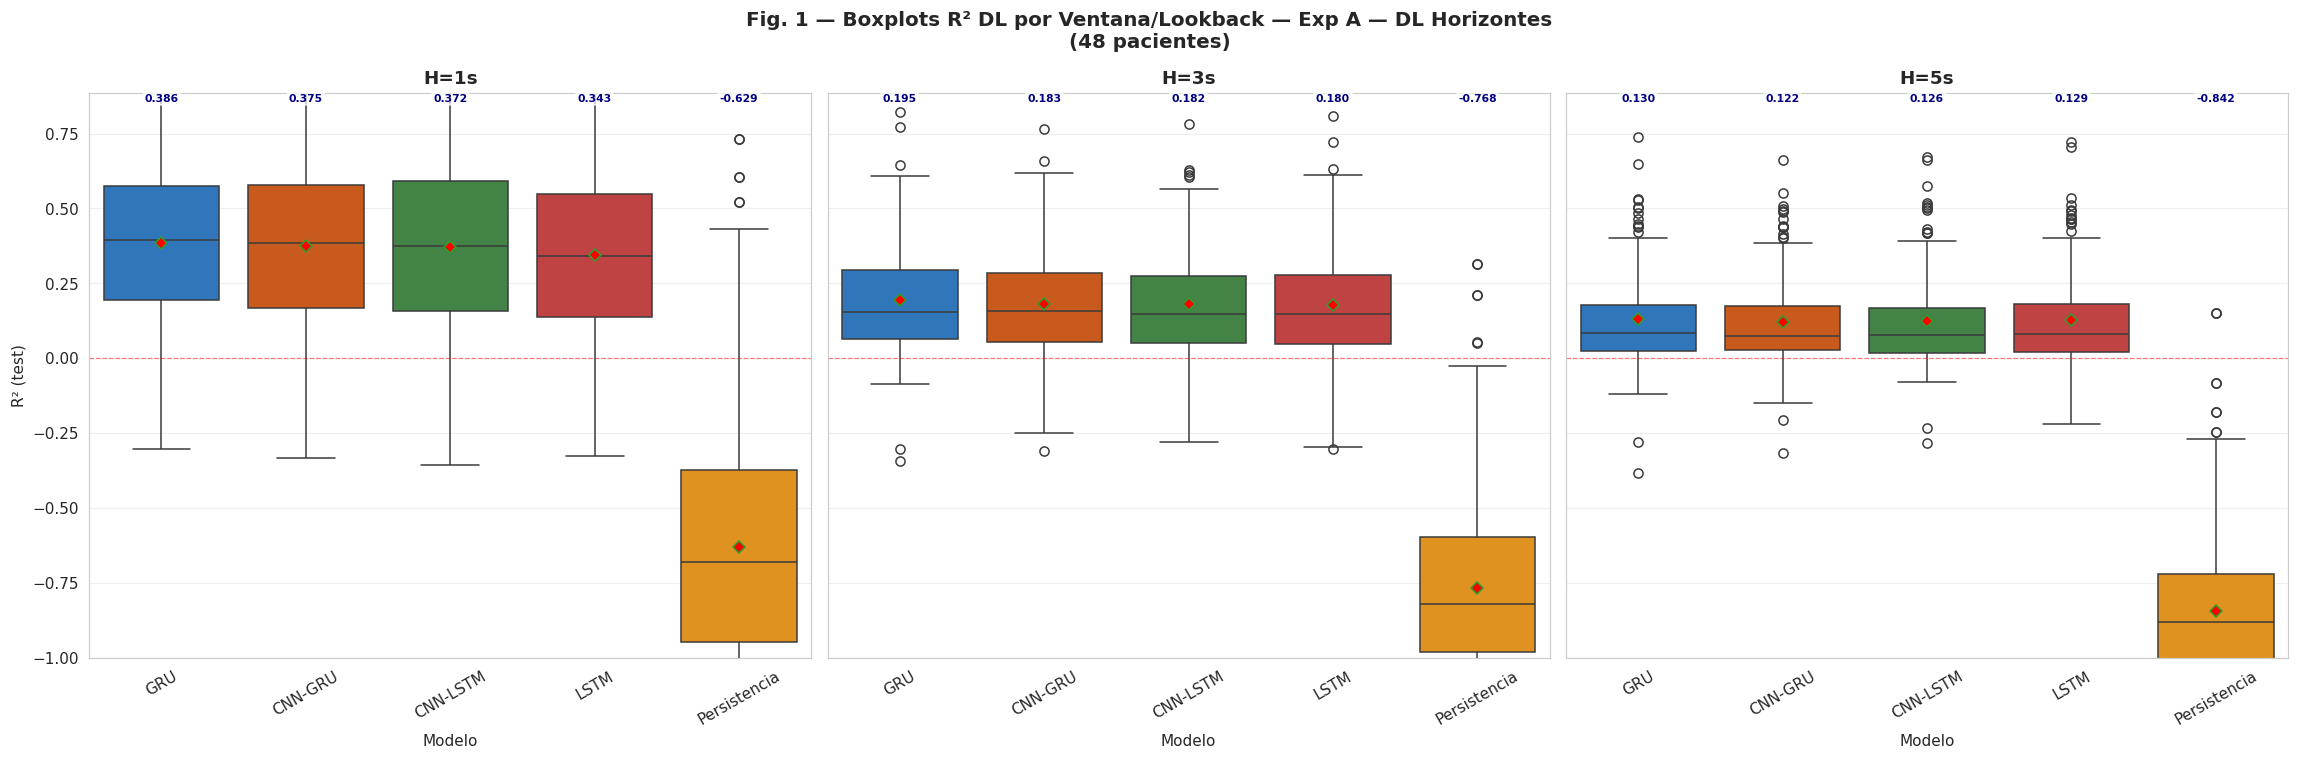

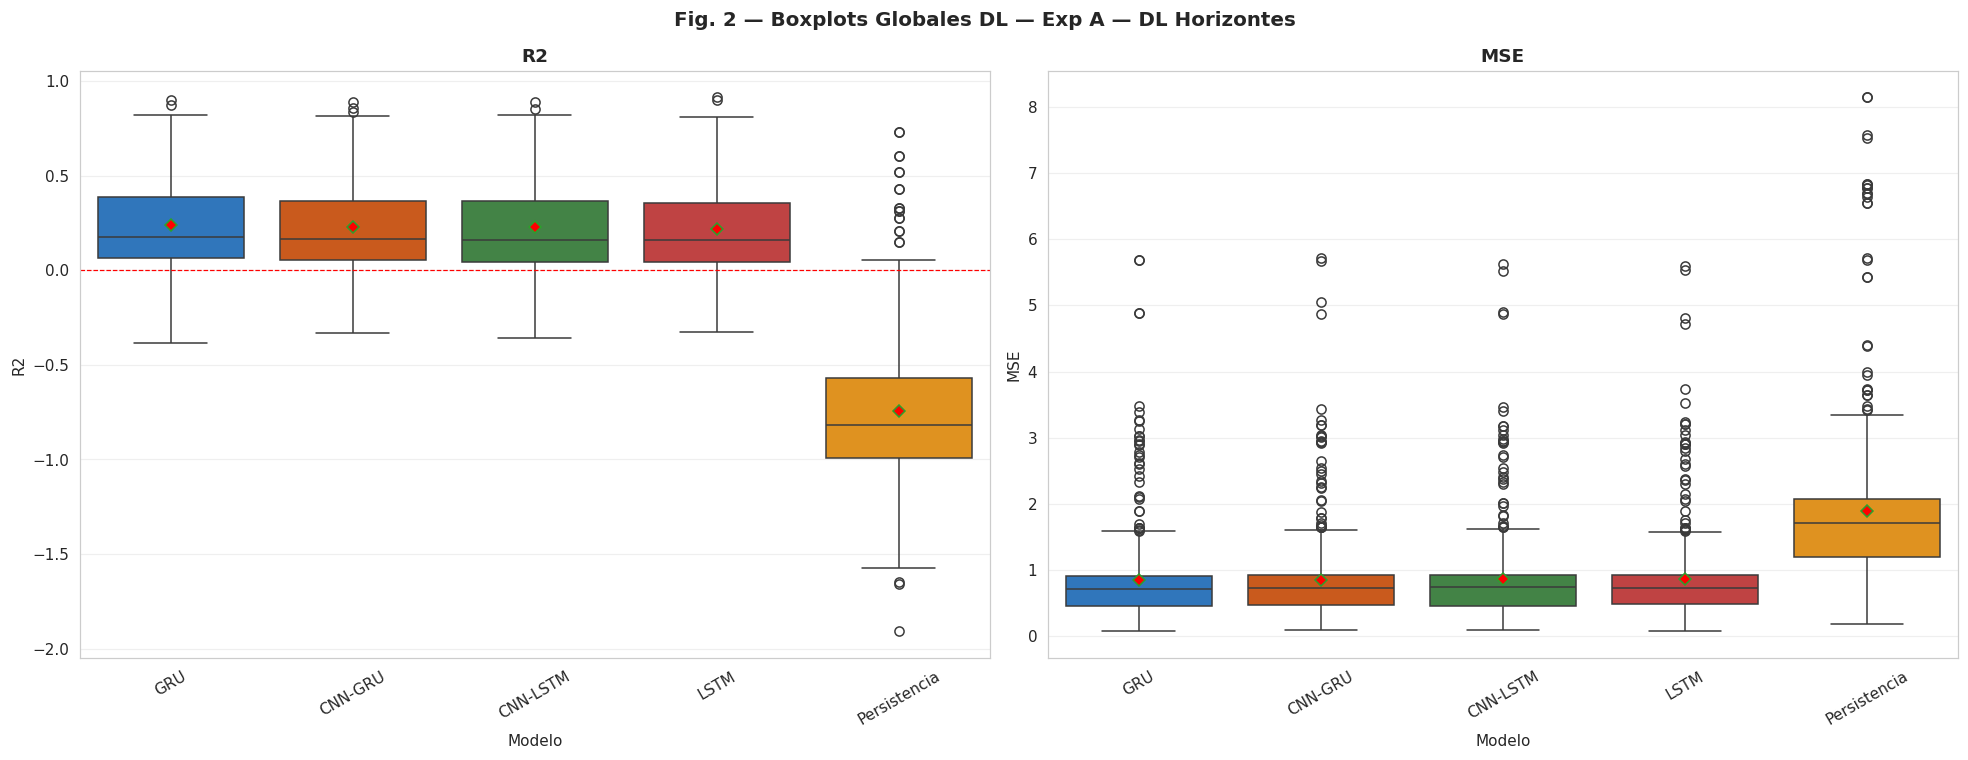

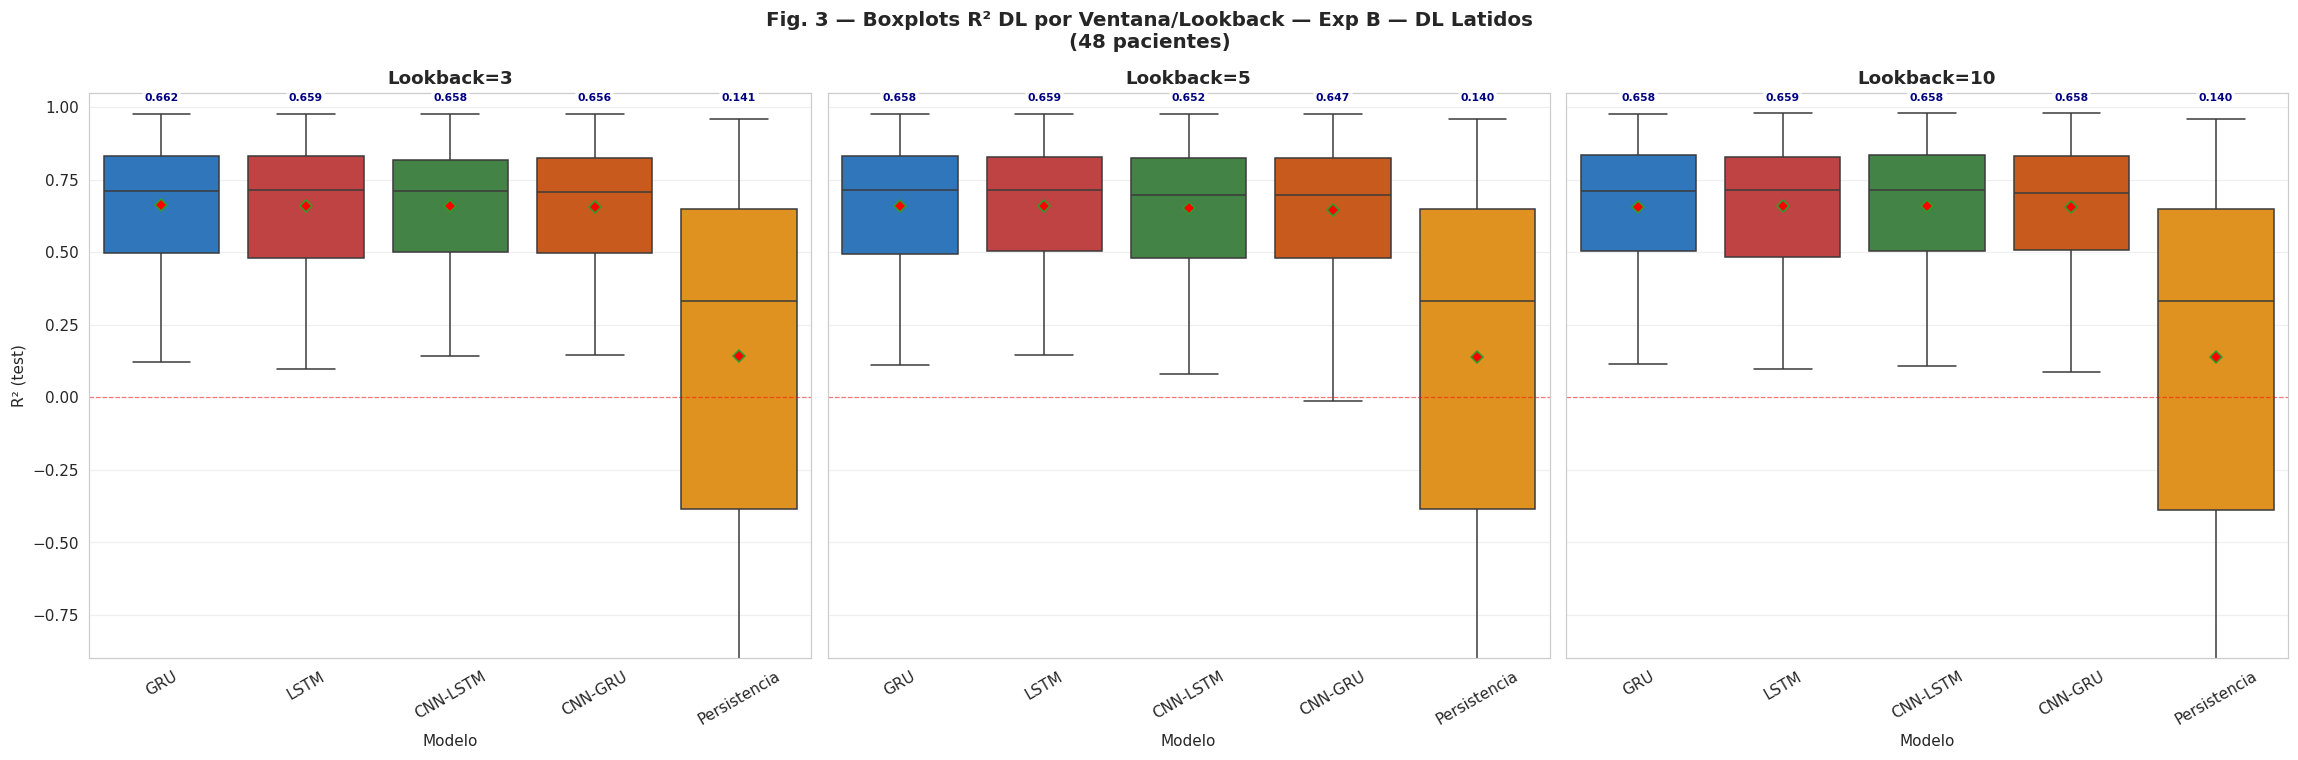

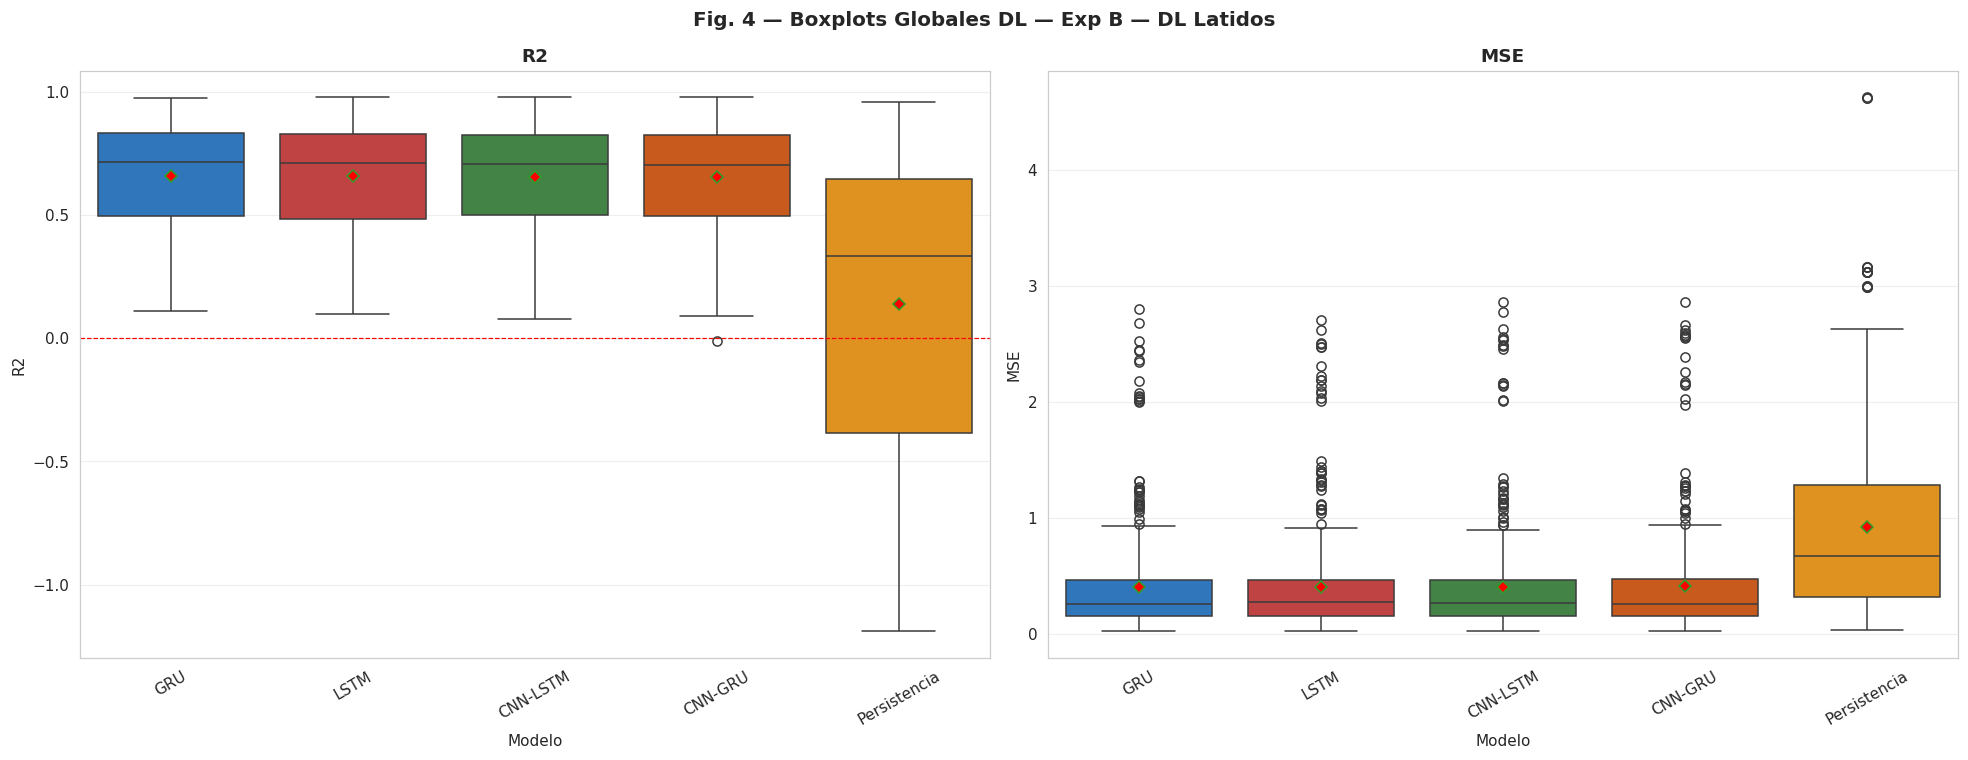

In [ ]:

# ══════════════════════════════════════════════════════════════════
# BOXPLOTS POR MODELO DL (gráficas de bigotes)
# ══════════════════════════════════════════════════════════════════

PALETA_DL = {
    'LSTM'         : '#D32F2F',
    'GRU'          : '#1976D2',
    'CNN-LSTM'     : '#388E3C',
    'CNN-GRU'      : '#E65100',
    'Persistencia' : '#FF9800',
}

for tag, df_exp in [('Exp A — DL Horizontes', df_A),
                    ('Exp B — DL Latidos', df_B)]:
    if df_exp.empty: continue

    orden = df_exp.groupby('Modelo')['R2'].mean().sort_values(ascending=False).index.tolist()
    pal_ord = [PALETA_DL.get(m, '#888888') for m in orden]

    grp_col = 'Horizonte_seg' if 'Horizonte_seg' in df_exp.columns else (
              'Ventana_seg'   if 'Ventana_seg'   in df_exp.columns else 'Lookback')
    grp_vals = sorted(df_exp[grp_col].unique()) if grp_col in df_exp.columns else [None]
    n_grp  = max(len(grp_vals), 1)
    FIG_NUM = 1 if 'A' in tag else 3

    if n_grp > 1 and grp_vals[0] is not None:
        fig, axes = plt.subplots(1, n_grp, figsize=(7 * n_grp, 7), sharey=True)
        if n_grp == 1: axes = [axes]
        fig.suptitle(f'Fig. {FIG_NUM} — Boxplots R² DL por Ventana/Lookback — {tag}\n'
                     f'({len(df_exp.Paciente.unique())} pacientes)',
                     fontsize=13, fontweight='bold')

        y_min = max(df_exp['R2'].quantile(0.01), -1.0)
        y_max = min(df_exp['R2'].quantile(0.99) + 0.1, 1.05)

        for ax, gv in zip(axes, grp_vals):
            sub = df_exp[df_exp[grp_col] == gv]
            sns.boxplot(data=sub, x='Modelo', y='R2', order=orden,
                        palette=pal_ord, ax=ax, showmeans=True,
                        meanprops={'marker': 'D', 'markerfacecolor': 'red', 'markersize': 6})
            ax.axhline(0, color='red', ls='--', lw=0.8, alpha=0.5)
            lbl = (f'H={gv}s' if 'Horizonte' in grp_col else
                   f'W={gv}s' if 'Ventana' in grp_col else f'Lookback={gv}')
            ax.set_title(lbl, fontweight='bold')
            ax.set_ylabel('R² (test)')
            ax.set_ylim(y_min, y_max)
            ax.tick_params(axis='x', rotation=30)
            ax.grid(True, alpha=0.3, axis='y')

            medias = sub.groupby('Modelo')['R2'].mean().reindex(orden)
            for i, mu in enumerate(medias):
                if not np.isnan(mu):
                    ax.text(i, y_max - 0.03, f'{mu:.3f}', ha='center', fontsize=7,
                            color='navy', fontweight='bold',
                            bbox=dict(facecolor='white', alpha=0.7, pad=1))

        plt.tight_layout()
        fname = f'boxplot_DL_{tag[:5].strip()}_desglose.png'
        plt.savefig(os.path.join(RUTA_RESULTS, fname), dpi=150, bbox_inches='tight')
        plt.show()

    # Boxplots globales R² y MSE
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    fig.suptitle(f'Fig. {FIG_NUM+1} — Boxplots Globales DL — {tag}',
                 fontsize=13, fontweight='bold')
    for ax, col, cmap in zip(axes, ['R2', 'MSE'], ['RdYlGn', 'RdYlGn_r']):
        if col not in df_exp.columns: continue
        sns.boxplot(data=df_exp, x='Modelo', y=col, order=orden,
                    palette=pal_ord, ax=ax, showmeans=True,
                    meanprops={'marker': 'D', 'markerfacecolor': 'red', 'markersize': 6})
        if col == 'R2':
            ax.axhline(0, color='red', ls='--', lw=0.8)
        ax.set_title(col, fontweight='bold')
        ax.tick_params(axis='x', rotation=30)
        ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    fname_g = f'boxplot_DL_{tag[:5].strip()}_global.png'
    plt.savefig(os.path.join(RUTA_RESULTS, fname_g), dpi=150, bbox_inches='tight')
    plt.show()


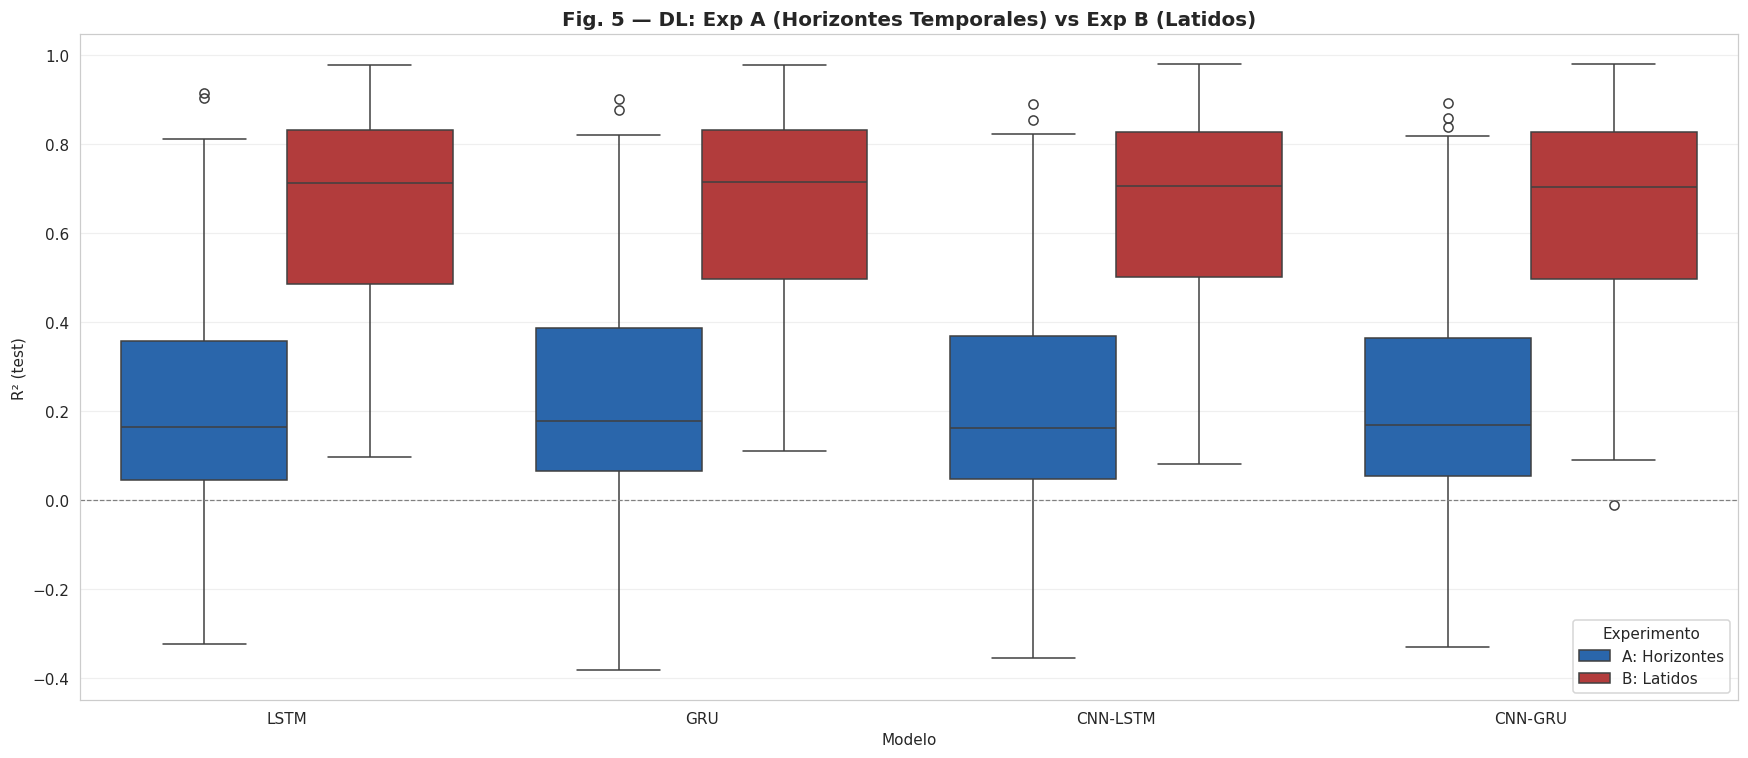

In [18]:
# ══════════════════════════════════════════════════════════════════
# BOXPLOT COMPARATIVO: Exp A vs Exp B en DL
# ══════════════════════════════════════════════════════════════════

if not df_A.empty and not df_B.empty:
    # Modelos DL comunes en ambos experimentos (sin Persistencia)
    modelos_dl = [m for m in ['LSTM', 'GRU', 'CNN-LSTM', 'CNN-GRU']
                  if m in df_A.Modelo.unique() and m in df_B.Modelo.unique()]

    if modelos_dl:
        df_cmp = pd.concat([
            df_A[df_A.Modelo.isin(modelos_dl)][['Modelo', 'R2']]
                .assign(Experimento='A: Horizontes'),
            df_B[df_B.Modelo.isin(modelos_dl)][['Modelo', 'R2']]
                .assign(Experimento='B: Latidos'),
        ])

        fig, ax = plt.subplots(figsize=(16, 7))
        sns.boxplot(data=df_cmp, x='Modelo', y='R2', hue='Experimento',
                    palette=['#1565C0', '#C62828'], ax=ax, order=modelos_dl)
        ax.axhline(0, color='gray', ls='--', lw=0.8)
        ax.set_title('Fig. 5 — DL: Exp A (Horizontes Temporales) vs Exp B (Latidos)',
                     fontweight='bold', fontsize=13)
        ax.set_ylabel('R² (test)')
        ax.legend(title='Experimento')
        ax.grid(True, alpha=0.3, axis='y')
        plt.tight_layout()
        plt.savefig(os.path.join(RUTA_RESULTS, 'boxplot_DL_A_vs_B.png'),
                    dpi=150, bbox_inches='tight')
        plt.show()

---
## BLOQUE 9 — Comparación NB1 (Tradicionales) vs NB2 (DL)

In [19]:
# ══════════════════════════════════════════════════════════════════
# TABLA COMPARATIVA: Modelos Tradicionales (NB1) vs DL (NB2)
# ══════════════════════════════════════════════════════════════════

# Cargar resultados de NB1
ruta_nb1_A = os.path.join(RUTA_NB1, 'resultados_A.csv')
ruta_nb1_B = os.path.join(RUTA_NB1, 'resultados_B.csv')

df_nb1_A = pd.read_csv(ruta_nb1_A) if os.path.exists(ruta_nb1_A) else pd.DataFrame()
df_nb1_B = pd.read_csv(ruta_nb1_B) if os.path.exists(ruta_nb1_B) else pd.DataFrame()

print('=' * 70)
print('  COMPARACIÓN: Modelos Tradicionales (NB1) vs Deep Learning (NB2)')
print('=' * 70)

filas_comp = []

# NB1 Exp A (tradicionales por tiempo)
if not df_nb1_A.empty:
    for mod in df_nb1_A.Modelo.unique():
        sub = df_nb1_A[df_nb1_A.Modelo == mod]
        filas_comp.append({
            'Notebook': 'NB1 (Tradicional)',
            'Experimento': 'A: Tiempo',
            'Modelo': mod,
            'R2_train': f"{sub['R2_train'].mean():.4f} ± {sub['R2_train'].std():.4f}" if 'R2_train' in sub.columns else 'N/A',
            'R2_test': f"{sub['R2'].mean():.4f} ± {sub['R2'].std():.4f}",
            'MSE': f"{sub['MSE'].mean():.6f} ± {sub['MSE'].std():.6f}" if 'MSE' in sub.columns else 'N/A',
            'R2_media': sub['R2'].mean(),
        })

# NB1 Exp B (tradicionales por latidos)
if not df_nb1_B.empty:
    for mod in df_nb1_B.Modelo.unique():
        sub = df_nb1_B[df_nb1_B.Modelo == mod]
        filas_comp.append({
            'Notebook': 'NB1 (Tradicional)',
            'Experimento': 'B: Latidos',
            'Modelo': mod,
            'R2_train': f"{sub['R2_train'].mean():.4f} ± {sub['R2_train'].std():.4f}" if 'R2_train' in sub.columns else 'N/A',
            'R2_test': f"{sub['R2'].mean():.4f} ± {sub['R2'].std():.4f}",
            'MSE': f"{sub['MSE'].mean():.6f} ± {sub['MSE'].std():.6f}" if 'MSE' in sub.columns else 'N/A',
            'R2_media': sub['R2'].mean(),
        })

# NB2 Exp A (DL por tiempo)
if not df_A.empty:
    for mod in df_A.Modelo.unique():
        sub = df_A[df_A.Modelo == mod]
        filas_comp.append({
            'Notebook': 'NB2 (Deep Learning)',
            'Experimento': 'A: Tiempo',
            'Modelo': mod,
            'R2_train': f"{sub['R2_train'].mean():.4f} ± {sub['R2_train'].std():.4f}" if 'R2_train' in sub.columns else 'N/A',
            'R2_test': f"{sub['R2'].mean():.4f} ± {sub['R2'].std():.4f}",
            'MSE': f"{sub['MSE'].mean():.6f} ± {sub['MSE'].std():.6f}" if 'MSE' in sub.columns else 'N/A',
            'R2_media': sub['R2'].mean(),
        })

# NB2 Exp B (DL por latidos)
if not df_B.empty:
    for mod in df_B.Modelo.unique():
        sub = df_B[df_B.Modelo == mod]
        filas_comp.append({
            'Notebook': 'NB2 (Deep Learning)',
            'Experimento': 'B: Latidos',
            'Modelo': mod,
            'R2_train': f"{sub['R2_train'].mean():.4f} ± {sub['R2_train'].std():.4f}" if 'R2_train' in sub.columns else 'N/A',
            'R2_test': f"{sub['R2'].mean():.4f} ± {sub['R2'].std():.4f}",
            'MSE': f"{sub['MSE'].mean():.6f} ± {sub['MSE'].std():.6f}" if 'MSE' in sub.columns else 'N/A',
            'R2_media': sub['R2'].mean(),
        })

df_comp = pd.DataFrame(filas_comp).sort_values('R2_media', ascending=False)
# Tabla coloreada por R² media
try:
    styled = (df_comp[['Notebook', 'Experimento', 'Modelo', 'R2_train', 'R2_test', 'MSE', 'R2_media']]
              .style
              .background_gradient(subset=['R2_media'], cmap='RdYlGn', vmin=-0.5, vmax=1)
              .format({'R2_media': '{:.4f}'})
              .set_caption('Ranking Global: NB1 (Tradicional) vs NB2 (Deep Learning)'))
    display(styled)
except Exception:
    display(df_comp[['Notebook', 'Experimento', 'Modelo', 'R2_train', 'R2_test', 'MSE']])

df_comp.to_csv(os.path.join(RUTA_RESULTS, 'tabla_comparativa_NB1_NB2.csv'), index=False)
print(f'\nTabla comparativa guardada.')

  COMPARACIÓN: Modelos Tradicionales (NB1) vs Deep Learning (NB2)


,Notebook,Experimento,Modelo,R2_train,R2_test,MSE,R2_media
19,NB2 (Deep Learning),B: Latidos,GRU,0.7966 ± 0.1395,0.6592 ± 0.2123,0.399653 ± 0.446927,0.6592
18,NB2 (Deep Learning),B: Latidos,LSTM,0.7852 ± 0.1426,0.6592 ± 0.2125,0.403567 ± 0.458181,0.6592
20,NB2 (Deep Learning),B: Latidos,CNN-LSTM,0.7905 ± 0.1434,0.6559 ± 0.2131,0.404835 ± 0.463327,0.6559
21,NB2 (Deep Learning),B: Latidos,CNN-GRU,0.7953 ± 0.1458,0.6536 ± 0.2170,0.407186 ± 0.465859,0.6536
10,NB1 (Tradicional),B: Latidos,SVR_rbf,0.8722 ± 0.1185,0.6454 ± 0.3110,0.158466 ± 0.506403,0.6454
9,NB1 (Tradicional),B: Latidos,RF,0.8495 ± 0.0948,0.6264 ± 0.2019,0.418494 ± 0.357136,0.6264
11,NB1 (Tradicional),B: Latidos,MLP,0.7595 ± 0.1628,0.5829 ± 0.2449,0.454277 ± 0.362955,0.5829
8,NB1 (Tradicional),B: Latidos,DT,0.8257 ± 0.1161,0.4520 ± 0.2899,0.599798 ± 0.462335,0.4520
14,NB2 (Deep Learning),A: Tiempo,GRU,0.3957 ± 0.2202,0.2371 ± 0.2322,0.848649 ± 0.711623,0.2371
16,NB2 (Deep Learning),A: Tiempo,CNN-GRU,0.4034 ± 0.2296,0.2267 ± 0.2320,0.856316 ± 0.701551,0.2267



Tabla comparativa guardada.


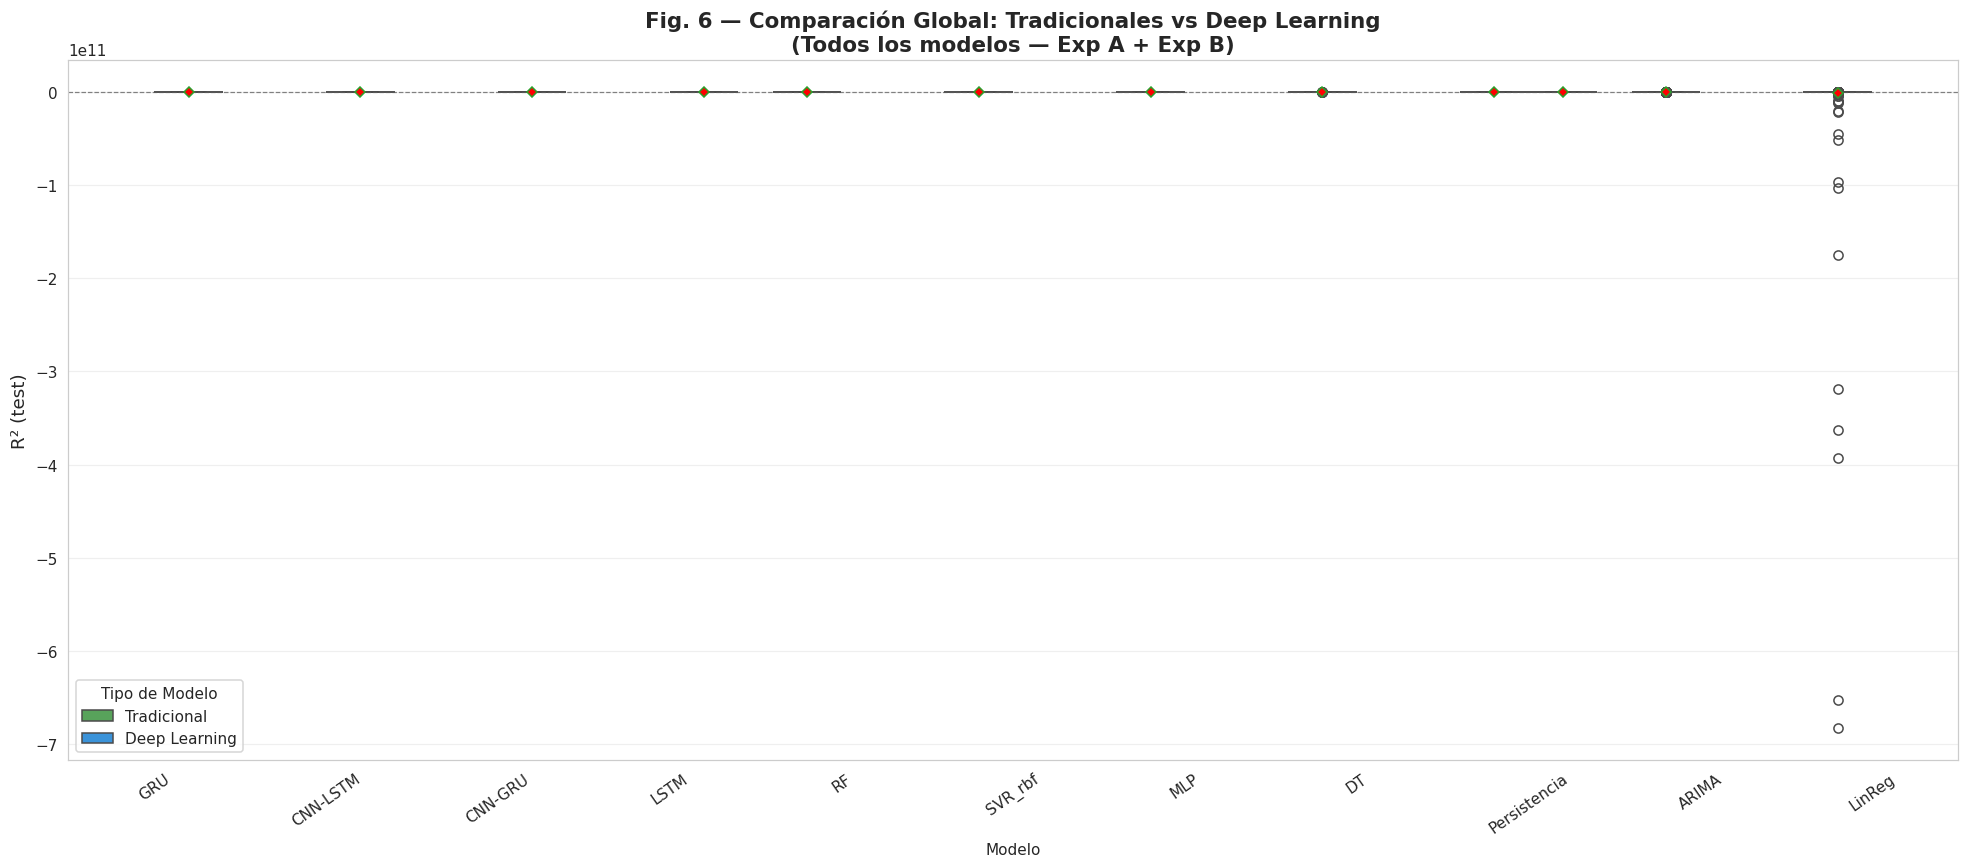

In [20]:
# ══════════════════════════════════════════════════════════════════
# BOXPLOT GLOBAL: Tradicionales vs DL (todos los modelos)
# ══════════════════════════════════════════════════════════════════

frames = []
if not df_nb1_A.empty:
    frames.append(df_nb1_A[['Modelo', 'R2']].assign(Tipo='Tradicional', Exp='A: Tiempo'))
if not df_nb1_B.empty:
    frames.append(df_nb1_B[['Modelo', 'R2']].assign(Tipo='Tradicional', Exp='B: Latidos'))
if not df_A.empty:
    frames.append(df_A[['Modelo', 'R2']].assign(Tipo='Deep Learning', Exp='A: Tiempo'))
if not df_B.empty:
    frames.append(df_B[['Modelo', 'R2']].assign(Tipo='Deep Learning', Exp='B: Latidos'))

if frames:
    df_all = pd.concat(frames, ignore_index=True)

    # Orden por R² media
    orden_global = (df_all.groupby('Modelo')['R2'].mean()
                    .sort_values(ascending=False).index.tolist())

    fig, ax = plt.subplots(figsize=(18, 8))
    sns.boxplot(data=df_all, x='Modelo', y='R2', hue='Tipo',
                palette={'Tradicional': '#4CAF50', 'Deep Learning': '#2196F3'},
                ax=ax, order=orden_global, showmeans=True,
                meanprops={'marker': 'D', 'markerfacecolor': 'red', 'markersize': 5})
    ax.axhline(0, color='gray', ls='--', lw=0.8)
    ax.set_title('Fig. 6 — Comparación Global: Tradicionales vs Deep Learning\n'
                 '(Todos los modelos — Exp A + Exp B)',
                 fontweight='bold', fontsize=14)
    ax.set_ylabel('R² (test)', fontsize=12)
    ax.tick_params(axis='x', rotation=35)
    ax.legend(title='Tipo de Modelo', fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.savefig(os.path.join(RUTA_RESULTS, 'boxplot_global_trad_vs_dl.png'),
                dpi=150, bbox_inches='tight')
    plt.show()

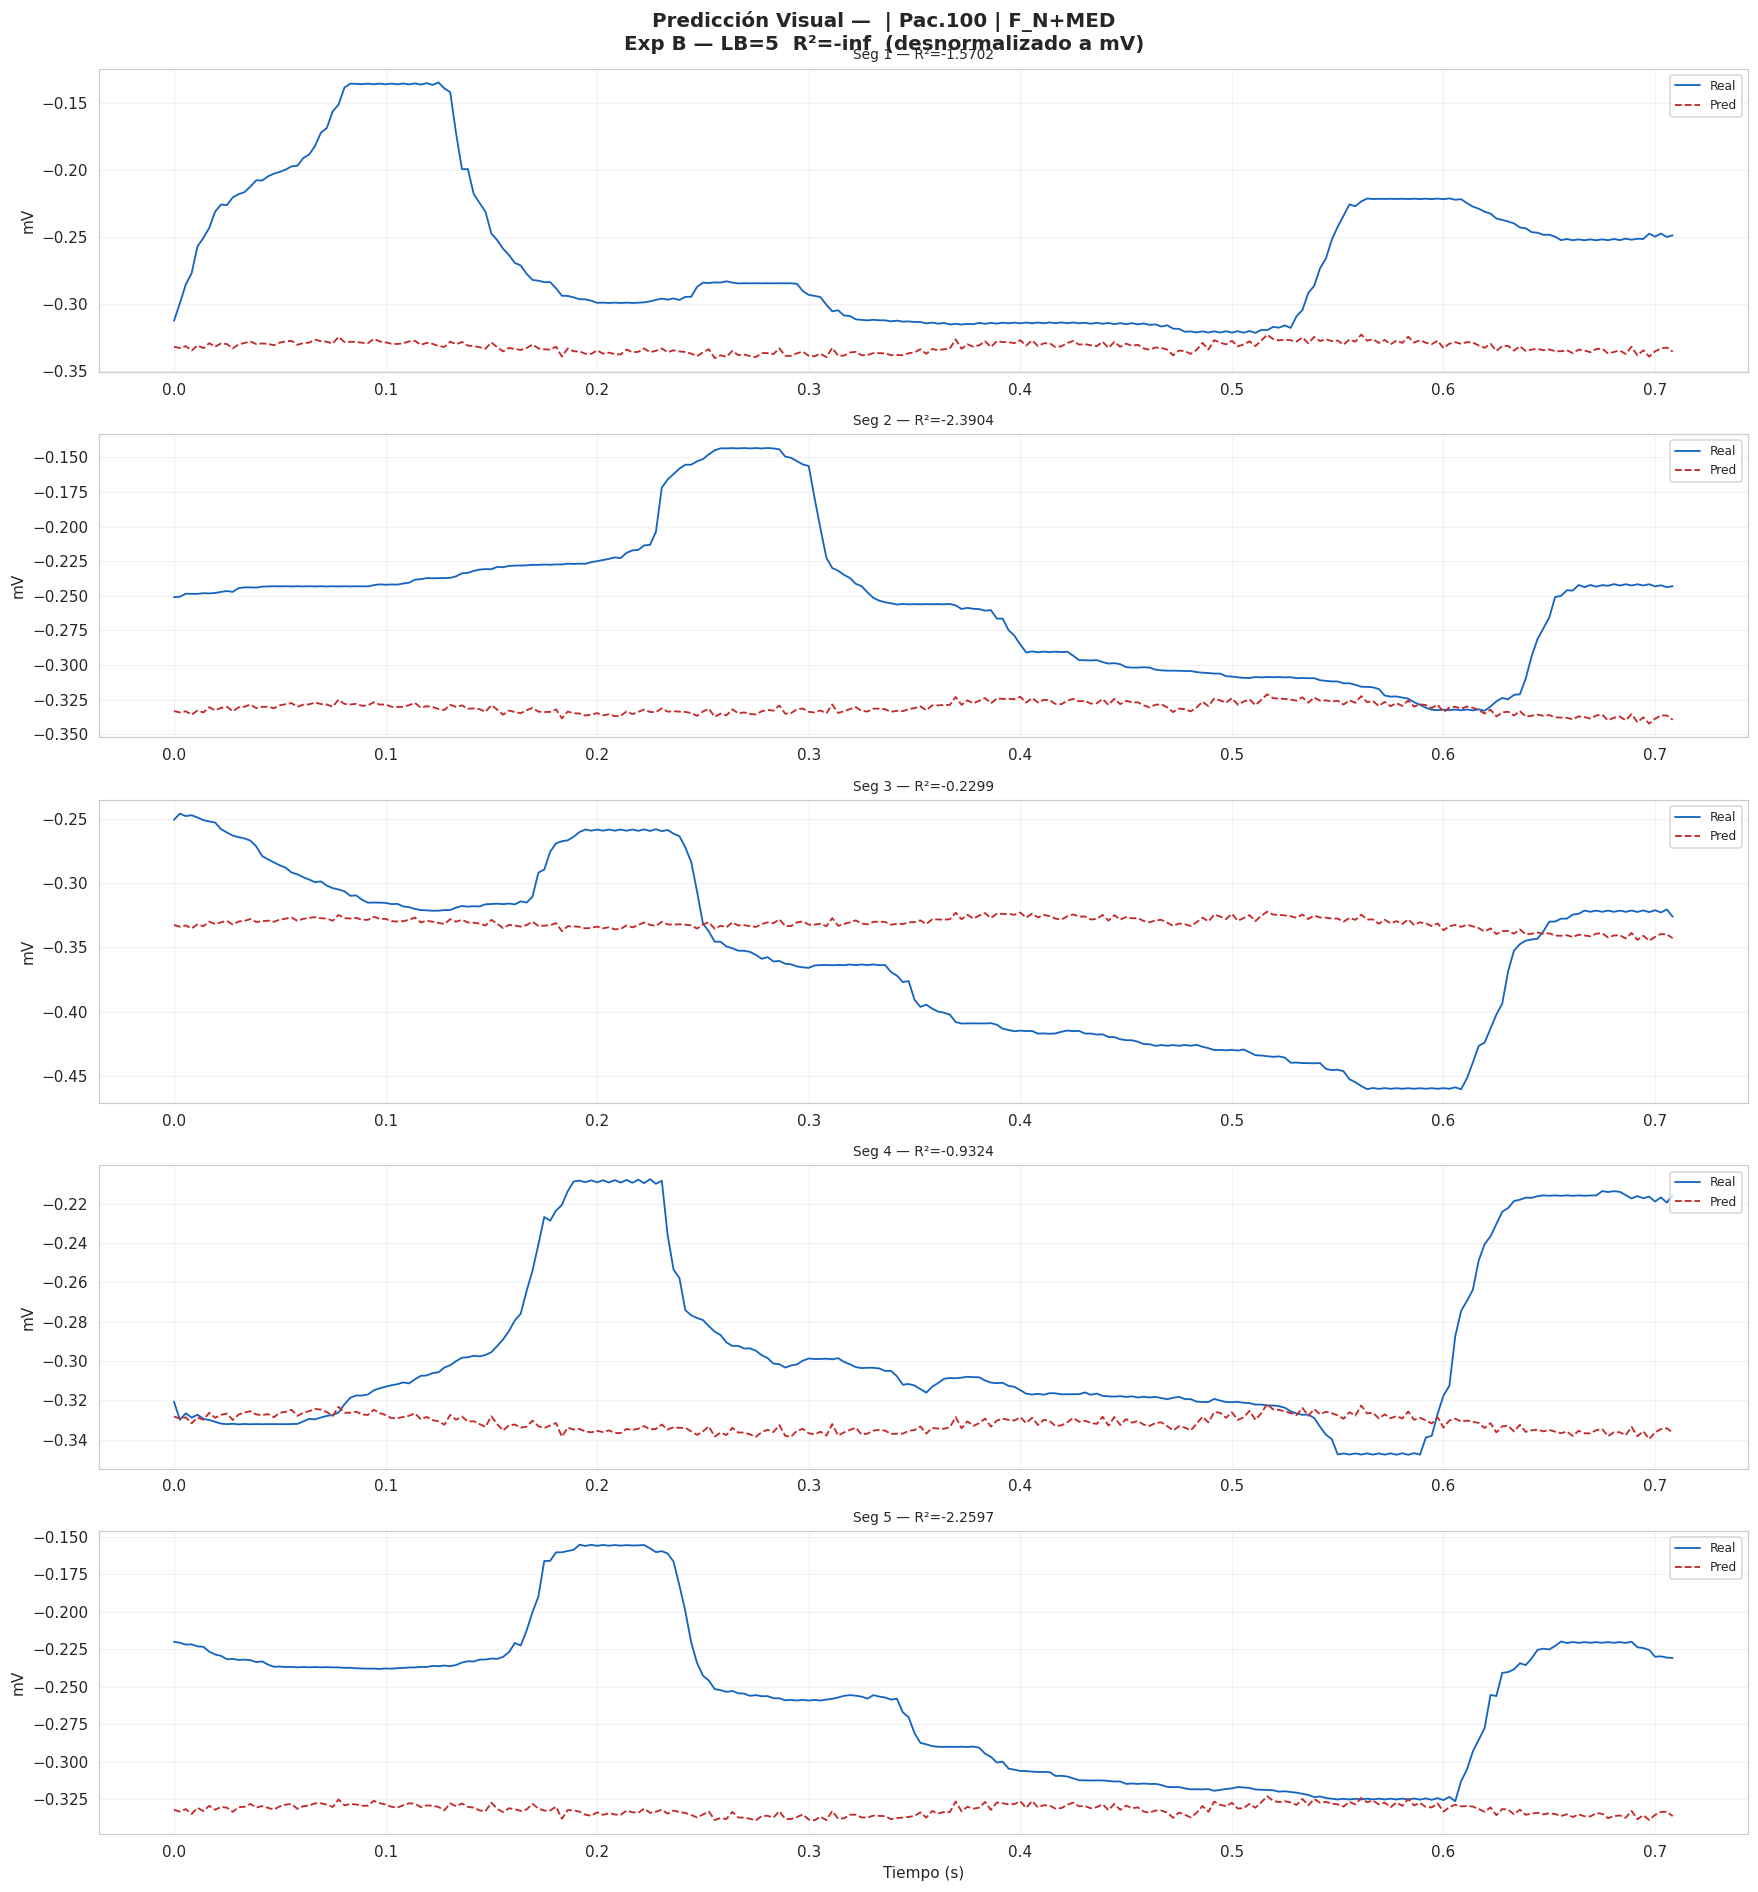

Figura guardada: prediccion_DL_Exp A_ganador.png


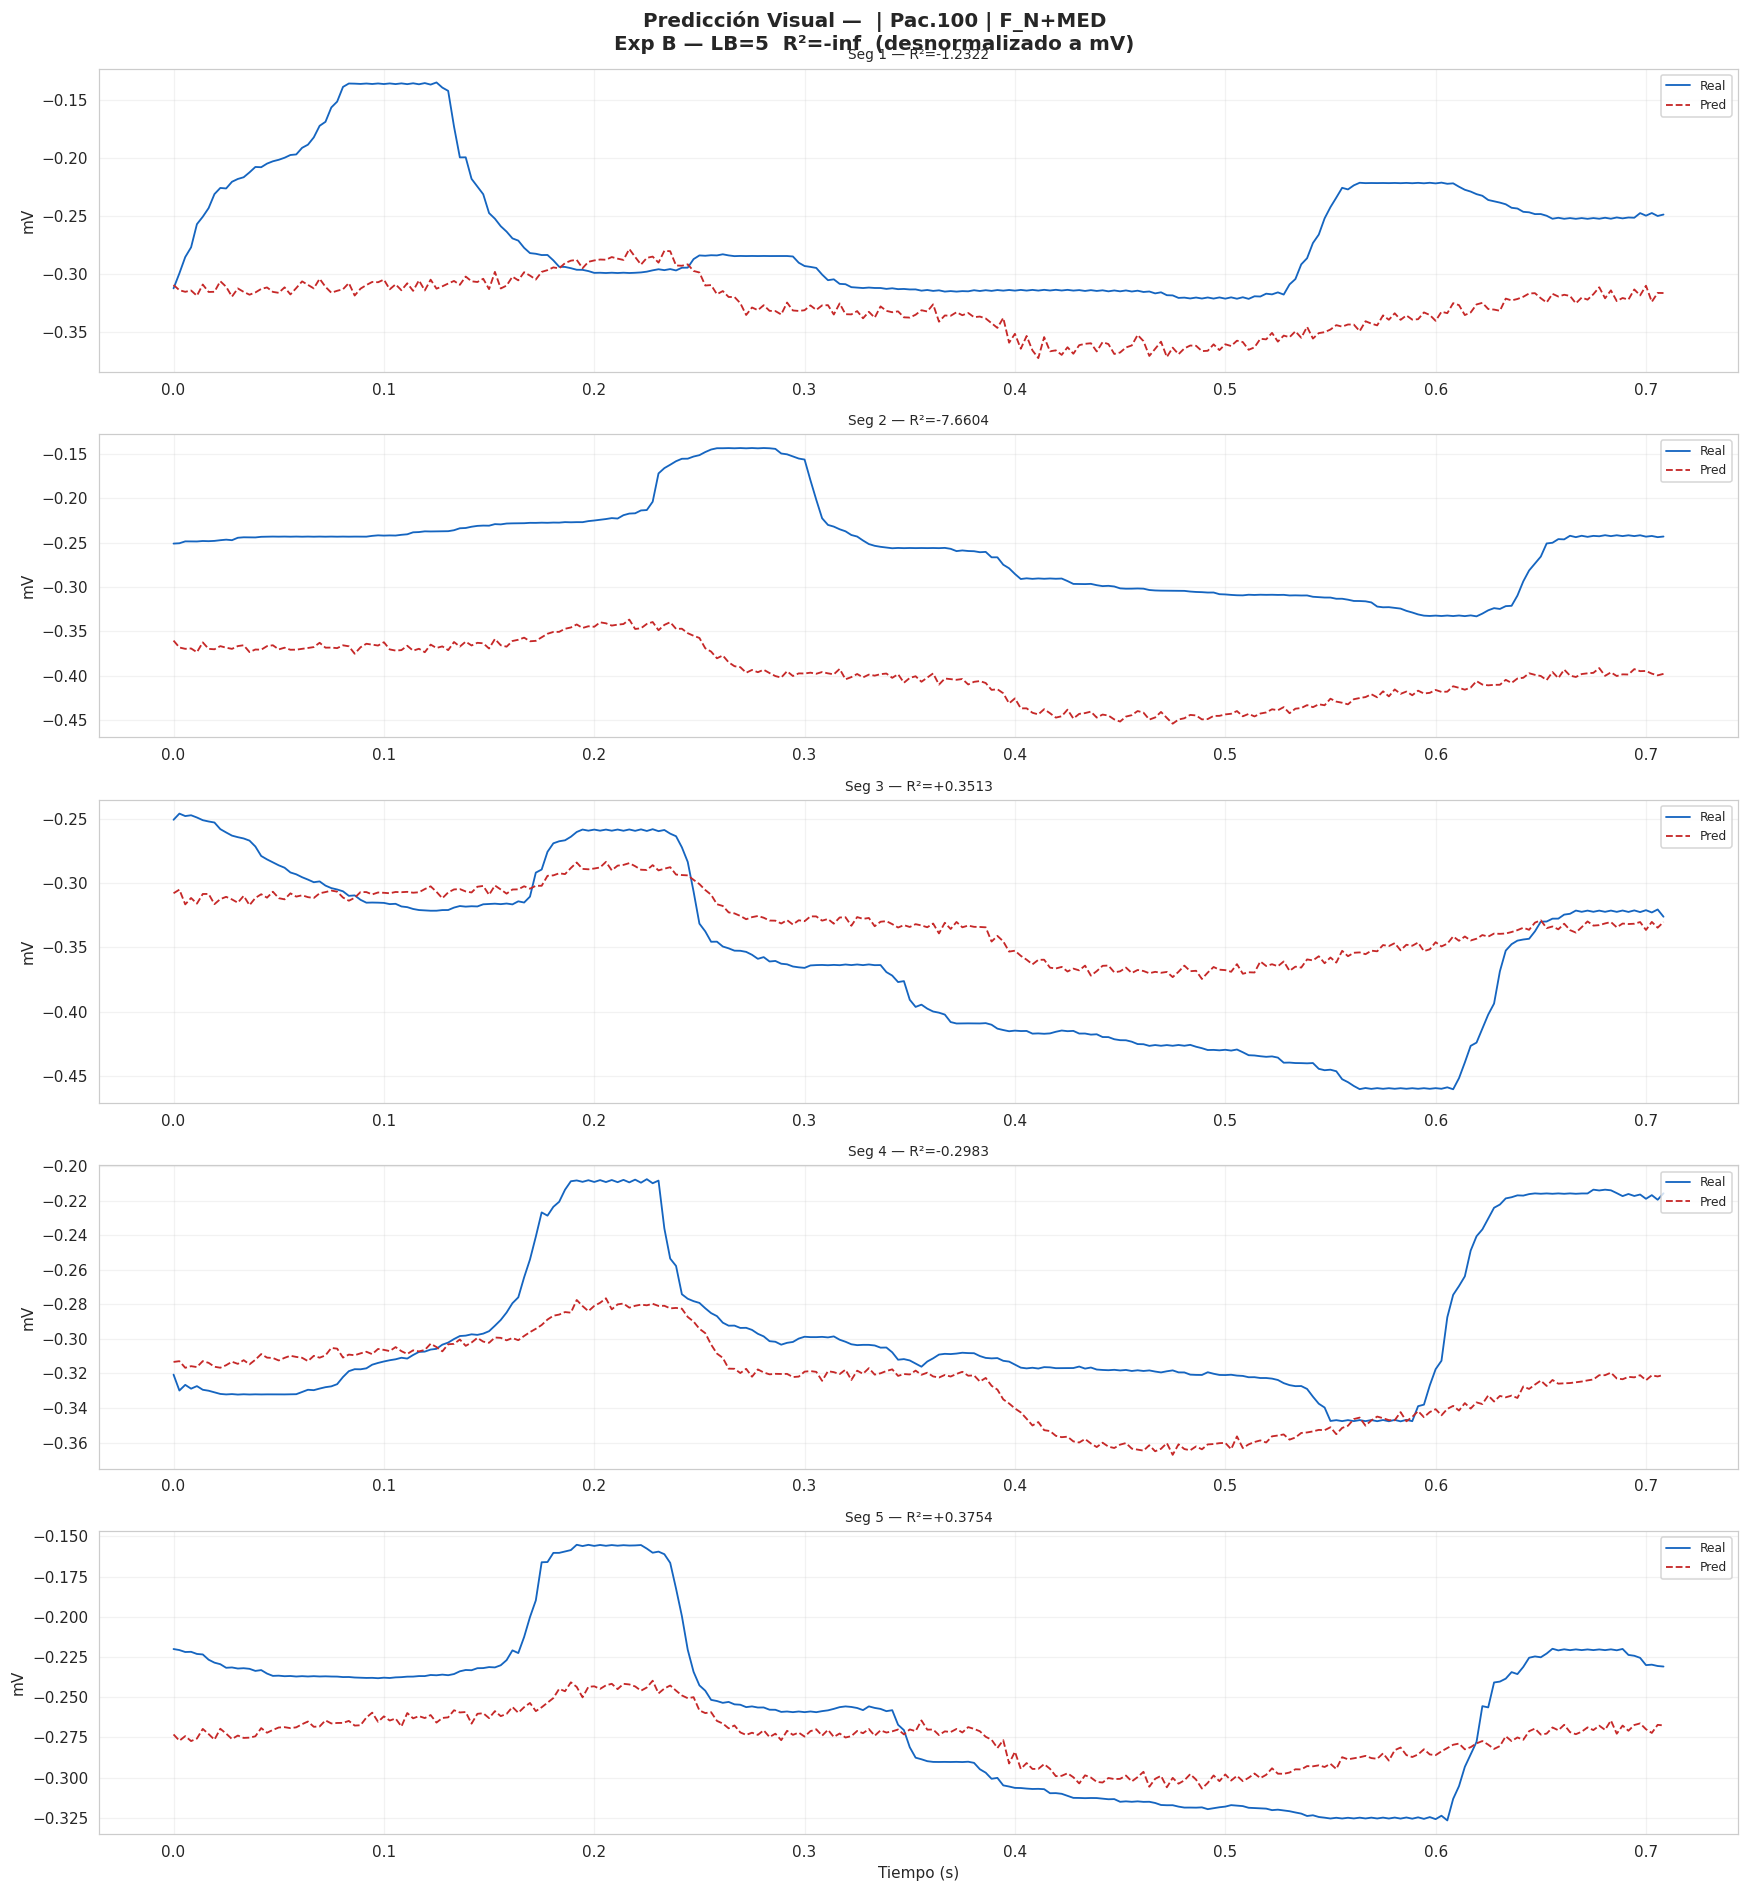

Figura guardada: prediccion_DL_Exp B_ganador.png


In [21]:
# ══════════════════════════════════════════════════════════════════
# PREDICCIÓN VISUAL — Modelos ganadores DL vs señal real
# Carga los modelos guardados (ganador_A_global_NB2.keras, ganador_B_global_NB2.keras)
# ══════════════════════════════════════════════════════════════════

def _cargar_ganador(tracker):
    """Carga el modelo ganador: desde objeto en memoria o desde disco."""
    if tracker.get('model') is not None:
        return tracker['model']
    ruta = tracker.get('ruta', '')
    if os.path.exists(ruta):
        return keras.models.load_model(ruta)
    return None

for tag, df_exp, tracker in [
    ('Exp A — DL Horizontes', df_A, mejor_global_A),
    ('Exp B — DL Latidos',    df_B, mejor_global_B),
]:
    if df_exp.empty: continue
    model_ganador = _cargar_ganador(tracker)
    if model_ganador is None:
        print(f'[!] No hay modelo ganador para {tag}'); continue

    nom_g   = tracker.get('nom', 'Ganador')
    cfg_g   = tracker.get('config', {})
    r2_g    = tracker.get('r2', 0)

    # Reproducir datos del paciente/filtro del ganador
    pid_vis  = cfg_g.get('pid', REGISTROS_OK[0])
    f_vis    = cfg_g.get('filtro', FILTROS_SEL[0])
    if f_vis not in FILTROS: f_vis = list(FILTROS.keys())[0]

    s_vis, ann_vis = cargar_ecg(str(pid_vis))
    if s_vis is None: continue
    sf_vis = aplica(s_vis, FILTROS[f_vis])

    if 'horizonte_s' in cfg_g:
        # Exp A
        hs_vis = int(cfg_g.get('horizonte_s', 1))
        h_mues_vis = hs_vis * FS
        Xv, yv = segmentar_multistep_dl(sf_vis, VENTANA_L_MUES, h_mues_vis)
        Xtr_v, ytr_v, Xte_v, yte_v = split_temporal(Xv, yv)
        Xtr_vn, Xte_vn, mv, sv_std = zscore_3d(Xtr_v, Xte_v)
        _, yte_vn = zscore_y(ytr_v, yte_v, mv, sv_std)
        titulo_exp = f'Exp A — H={hs_vis}s'
    else:
        # Exp B
        lb_vis = int(cfg_g.get('lookback', 5))
        beats_vis = extraer_latidos(sf_vis, ann_vis)
        Xv, yv = secuencias_latidos(beats_vis, n_lookback=lb_vis)
        Xtr_v, ytr_v, Xte_v, yte_v = split_temporal(Xv, yv)
        Xtr_vn, Xte_vn, mv, sv_std = zscore_3d(Xtr_v, Xte_v)
        _, yte_vn = zscore_y(ytr_v, yte_v, mv, sv_std)
        h_mues_vis = BEAT_LEN
        titulo_exp = f'Exp B — LB={lb_vis}'

    n_vis = min(5, len(Xte_vn))
    yp_n  = model_ganador.predict(Xte_vn[:n_vis], batch_size=BATCH_SIZE, verbose=0)

    # Desnormalizar
    y_real_vis = yte_v[:n_vis]
    y_pred_vis = yp_n * sv_std + mv

    fig, axes = plt.subplots(n_vis, 1, figsize=(16, 3.5 * n_vis), sharex=False)
    if n_vis == 1: axes = [axes]
    fig.suptitle(f'Predicción Visual — {nom_g} | Pac.{pid_vis} | {f_vis}\n'
                 f'{titulo_exp}  R²={r2_g:+.4f}  (desnormalizado a mV)',
                 fontsize=13, fontweight='bold')

    for k, ax in enumerate(axes):
        real_k = y_real_vis[k].flatten()
        pred_k = y_pred_vis[k].flatten()
        # Ajustar longitudes si difieren (modelo puede tener output ≠ target)
        n_min = min(len(real_k), len(pred_k))
        real_k = real_k[:n_min]
        pred_k = pred_k[:n_min]
        t_k = np.arange(n_min) / FS
        ax.plot(t_k, real_k, color='#1565C0', lw=1.2, label='Real')
        ax.plot(t_k, pred_k, color='#C62828', lw=1.2, ls='--', label='Pred')
        r2_k = r2_score(real_k, pred_k)
        ax.set_title(f'Seg {k+1} — R²={r2_k:+.4f}', fontsize=9)
        ax.set_ylabel('mV')
        ax.legend(loc='upper right', fontsize=8)
        ax.grid(True, alpha=0.25)

    axes[-1].set_xlabel('Tiempo (s)')
    plt.tight_layout()
    fname_vis = f'prediccion_DL_{tag[:5].strip()}_ganador.png'
    plt.savefig(os.path.join(RUTA_RESULTS, fname_vis), dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Figura guardada: {fname_vis}')


---
## BLOQUE 10 — Conclusiones y exportación

In [22]:

# ══════════════════════════════════════════════════════════════════
# CONCLUSIONES EXP1 — NB2 Deep Learning
# ══════════════════════════════════════════════════════════════════

print('=' * 70)
print('  CONCLUSIONES EXP1 — NB2 Deep Learning')
print('=' * 70)

for tag, df_exp in [('Exp A (Horizontes DL)', df_A), ('Exp B (Latidos DL)', df_B)]:
    if df_exp.empty: continue
    print(f'\n── {tag} ({len(df_exp)} registros) ──')
    for mod in df_exp.Modelo.unique():
        sub = df_exp[df_exp.Modelo == mod]
        r2_tr  = sub['R2_train'].mean() if 'R2_train' in sub.columns else np.nan
        r2_te  = sub['R2'].mean()
        r2_std = sub['R2'].std()
        print(f'  {mod:14s}: R²_train={r2_tr:+.4f}  R²_test={r2_te:+.4f} ± {r2_std:.4f}')

# ── Estado de modelos por paciente ────────────────────────────────
print(f'\n── Modelos guardados por paciente ──')
n_pac_A = sum(1 for f in os.listdir(RUTA_MODELOS)
              if f.startswith('ganador_A_pac') and f.endswith('.keras'))
n_pac_B = sum(1 for f in os.listdir(RUTA_MODELOS)
              if f.startswith('ganador_B_pac') and f.endswith('.keras'))
print(f'  Exp A: {n_pac_A}/{len(REGISTROS_OK)} pacientes')
print(f'  Exp B: {n_pac_B}/{len(REGISTROS_OK)} pacientes')

# ── Exportar config para NB3 ──────────────────────────────────────
config_nb3 = {
    'version'   : '2.4',
    'fecha'     : pd.Timestamp.now().isoformat(),
    'notebook'  : 'NB2_DeepLearning',
    'modelos_dl': list(MODELOS_DL.keys()),
    'guardado_modelos': {
        'estrategia': '1 modelo por paciente + 1 ganador global',
        'formato': '.keras',
        'patron_archivos': 'ganador_{A|B}_pac{pid}_NB2.keras + _metadata.json',
        'n_pac_A': n_pac_A,
        'n_pac_B': n_pac_B,
    },
    'correcciones': [
        'R2_train y R2_test reportados por separado',
        'Baseline Persistencia incluido como referencia naive en ambos experimentos',
        'Wilcoxon vs Persistencia (validación estadística DL > baseline)',
        'Guardado por paciente: 1 modelo ganador por paciente + 1 global',
        'LSTM, GRU, CNN-LSTM, CNN-GRU (4 modelos DL) + Persistencia (baseline)',
        'DTW corregido: promedio por secuencia individual',
        '48 pacientes MIT-BIH',
        'Celda de reconstrucción para re-entrenar modelos faltantes desde CSV',
    ],
}

# Ganador A
if not df_A.empty:
    dl_A = df_A[~df_A.Modelo.isin(['Persistencia'])]
    if not dl_A.empty:
        best_A = dl_A.groupby('Modelo')['R2'].mean()
        config_nb3['mejor_modelo_DL_A'] = best_A.idxmax()
        config_nb3['mejor_r2_DL_A']     = round(float(best_A.max()), 4)
        config_nb3['ganador_A_global']   = mejor_global_A.get('ruta', '')
        config_nb3['ganador_A_config']   = mejor_global_A.get('config', {})

# Ganador B
if not df_B.empty:
    dl_B = df_B[~df_B.Modelo.isin(['Persistencia'])]
    if not dl_B.empty:
        best_B = dl_B.groupby('Modelo')['R2'].mean()
        config_nb3['mejor_modelo_DL_B'] = best_B.idxmax()
        config_nb3['mejor_r2_DL_B']     = round(float(best_B.max()), 4)
        config_nb3['ganador_B_global']   = mejor_global_B.get('ruta', '')
        config_nb3['ganador_B_config']   = mejor_global_B.get('config', {})

ruta_cfg = os.path.join(RUTA_RESULTS, 'config_NB3.json')
with open(ruta_cfg, 'w', encoding='utf-8') as f:
    json.dump(config_nb3, f, indent=2, ensure_ascii=False)

print(f'\nConfig exportado: {ruta_cfg}')
print(json.dumps(config_nb3, indent=2, ensure_ascii=False))


  CONCLUSIONES EXP1 — NB2 Deep Learning

── Exp A (Horizontes DL) (2160 registros) ──
  LSTM          : R²_train=+0.3767  R²_test=+0.2174 ± 0.2295
  GRU           : R²_train=+0.3957  R²_test=+0.2371 ± 0.2322
  CNN-LSTM      : R²_train=+0.4025  R²_test=+0.2265 ± 0.2301
  CNN-GRU       : R²_train=+0.4034  R²_test=+0.2267 ± 0.2320
  Persistencia  : R²_train=-0.7034  R²_test=-0.7462 ± 0.3984

── Exp B (Latidos DL) (2160 registros) ──
  LSTM          : R²_train=+0.7852  R²_test=+0.6592 ± 0.2125
  GRU           : R²_train=+0.7966  R²_test=+0.6592 ± 0.2123
  CNN-LSTM      : R²_train=+0.7905  R²_test=+0.6559 ± 0.2131
  CNN-GRU       : R²_train=+0.7953  R²_test=+0.6536 ± 0.2170
  Persistencia  : R²_train=+0.1434  R²_test=+0.1405 ± 0.5937

── Modelos guardados por paciente ──
  Exp A: 48/48 pacientes
  Exp B: 48/48 pacientes

Config exportado: /content/drive/MyDrive/FORECASTING ECG/results/NB2/config_NB3.json
{
  "version": "2.4",
  "fecha": "2026-03-28T20:49:17.449215",
  "notebook": "NB2_DeepL

In [23]:

# ══════════════════════════════════════════════════════════════════
# VERIFICACIÓN FINAL DE ARTEFACTOS
# ══════════════════════════════════════════════════════════════════

artefactos_results = [
    'resultados_ExpA.csv',
    'resultados_ExpB.csv',
    'r2_train_test_Exp A.csv',
    'r2_train_test_Exp B.csv',
    'resumen_Exp A.csv',
    'resumen_Exp B.csv',
    'wilcoxon_vs_persistencia_Exp A.csv',
    'wilcoxon_vs_persistencia_Exp B.csv',
    'ic95_Exp A.csv',
    'ic95_Exp B.csv',
    'boxplot_DL_Exp A_desglose.png',
    'boxplot_DL_Exp B_desglose.png',
    'boxplot_DL_A_vs_B.png',
    'boxplot_global_trad_vs_dl.png',
    'prediccion_DL_Exp A_ganador.png',
    'prediccion_DL_Exp B_ganador.png',
    'tabla_comparativa_NB1_NB2.csv',
    'config_NB3.json',
]

artefactos_modelos_global = [
    os.path.join('modelos', 'ganador_A_global_NB2.keras'),
    os.path.join('modelos', 'ganador_B_global_NB2.keras'),
]

print(f'ARTEFACTOS RESULTS ({RUTA_RESULTS}):\n')
ok = 0
for a in artefactos_results:
    ruta = os.path.join(RUTA_RESULTS, a)
    if os.path.exists(ruta):
        kb = os.path.getsize(ruta) / 1024
        print(f'  OK   {a:55s} {kb:8.1f} KB'); ok += 1
    else:
        print(f'  ---  {a:55s} PENDIENTE')

print(f'\nMODELOS GANADORES GLOBALES:\n')
for a in artefactos_modelos_global:
    ruta = os.path.join(RUTA_RESULTS, a)
    if os.path.exists(ruta):
        mb = os.path.getsize(ruta) / 1e6
        print(f'  OK   {a:55s} {mb:8.2f} MB'); ok += 1
    else:
        print(f'  ---  {a:55s} PENDIENTE')

# ── Verificación de modelos por paciente ──────────────────────────
print(f'\nMODELOS POR PACIENTE:\n')
for prefijo, etiq in [('ganador_A_pac', 'Exp A'), ('ganador_B_pac', 'Exp B')]:
    archivos_pac = [f for f in os.listdir(RUTA_MODELOS)
                    if f.startswith(prefijo) and f.endswith('.keras')]
    n_meta = sum(1 for f in os.listdir(RUTA_MODELOS)
                 if f.startswith(prefijo) and f.endswith('_metadata.json'))
    print(f'  {etiq}: {len(archivos_pac)}/{len(REGISTROS_OK)} .keras  |  '
          f'{n_meta}/{len(REGISTROS_OK)} metadata')

    # Listar pacientes faltantes
    pids_guardados = set()
    for f in archivos_pac:
        # patrón: ganador_A_pac100_NB2.keras
        parts = f.replace('.keras', '').split('_pac')
        if len(parts) == 2:
            pid_str = parts[1].replace('_NB2', '')
            pids_guardados.add(pid_str)
    pids_faltantes = [p for p in REGISTROS_OK if p not in pids_guardados]
    if pids_faltantes:
        print(f'    Faltantes: {pids_faltantes[:10]}{"..." if len(pids_faltantes) > 10 else ""}')
    else:
        print(f'    Todos los pacientes tienen modelo guardado.')

total_artefactos = len(artefactos_results) + len(artefactos_modelos_global)
print(f'\n{ok}/{total_artefactos} artefactos globales generados')

print('\nCORRECCIONES APLICADAS:')
checks = [
    'R2 train + R2 test reportados por separado',
    'Tablas con media ± desviacion estandar',
    'Exp A: DL por horizontes temporales (L=5s fijo, H=1,3,5s)',
    'Exp B: DL por latidos (lookbacks=3,5,10)',
    '4 modelos DL: LSTM, GRU, CNN-LSTM, CNN-GRU',
    'Baseline Persistencia incluido en ambos experimentos',
    'Wilcoxon vs Persistencia (validación estadística DL > baseline)',
    'Guardado por paciente: 1 modelo ganador por paciente + 1 global',
    'Celda de reconstrucción para modelos faltantes desde CSV',
    'DTW corregido: promedio por secuencia individual',
    'Graficas de bigotes (boxplot) por modelo DL + Persistencia',
    'Comparacion NB1 vs NB2 en tabla unificada',
    'Boxplot global: Trad vs DL',
    '48 pacientes MIT-BIH',
    'Config exportado para NB3 con rutas a ganadores',
]
for c in checks:
    print(f'  [OK]  {c}')


ARTEFACTOS RESULTS (/content/drive/MyDrive/FORECASTING ECG/results/NB2):

  OK   resultados_ExpA.csv                                        217.2 KB
  OK   resultados_ExpB.csv                                        220.4 KB
  OK   r2_train_test_Exp A.csv                                      0.5 KB
  OK   r2_train_test_Exp B.csv                                      0.5 KB
  OK   resumen_Exp A.csv                                            0.8 KB
  OK   resumen_Exp B.csv                                            0.8 KB
  OK   wilcoxon_vs_persistencia_Exp A.csv                           0.1 KB
  OK   wilcoxon_vs_persistencia_Exp B.csv                           0.1 KB
  OK   ic95_Exp A.csv                                               0.2 KB
  OK   ic95_Exp B.csv                                               0.2 KB
  OK   boxplot_DL_Exp A_desglose.png                              115.3 KB
  OK   boxplot_DL_Exp B_desglose.png                               86.9 KB
  OK   boxplot_DL_A_vs_B.p

In [24]:
# ══════════════════════════════════════════════════════════════════
#  COMPRIMIR MODELOS (ganadores globales + por paciente)
#  Incluye: ganador_A/B_global_NB2.keras + ganador_A/B_pac*_NB2.keras
# ══════════════════════════════════════════════════════════════════
import tarfile

archivos_a_comprimir = []
for f in sorted(os.listdir(RUTA_MODELOS)):
    if f.endswith('.keras') or f.endswith('_metadata.json'):
        archivos_a_comprimir.append(os.path.join(RUTA_MODELOS, f))

if archivos_a_comprimir:
    destino_tar = os.path.join(RUTA_RESULTS, 'modelos_NB2.tar.gz')
    mb_sueltos  = sum(os.path.getsize(f) for f in archivos_a_comprimir) / 1e6
    print(f'Comprimiendo {len(archivos_a_comprimir)} archivo(s) '
          f'({mb_sueltos:.1f} MB) ...')
    with tarfile.open(destino_tar, 'w:gz') as tar:
        for f in archivos_a_comprimir:
            tar.add(f, arcname=os.path.join('modelos', os.path.basename(f)))
    mb_tar = os.path.getsize(destino_tar) / 1e6
    print(f'  ✓ {destino_tar}')
    print(f'  {mb_sueltos:.1f} MB → {mb_tar:.1f} MB comprimidos '
          f'(ahorro: {mb_sueltos - mb_tar:.1f} MB)')
    print(f'  Para extraer: tar -xzf modelos_NB2.tar.gz')

    # Resumen por tipo
    n_global = sum(1 for f in archivos_a_comprimir if 'global' in f and f.endswith('.keras'))
    n_pac = sum(1 for f in archivos_a_comprimir if '_pac' in f and f.endswith('.keras'))
    n_meta = sum(1 for f in archivos_a_comprimir if f.endswith('_metadata.json'))
    print(f'\n  Contenido: {n_global} globales | {n_pac} por-paciente | {n_meta} metadata')
else:
    print('[!] No se encontraron modelos para comprimir.')
    print(f'    Ruta esperada: {RUTA_MODELOS}')

Comprimiendo 196 archivo(s) (189.9 MB) ...
  ✓ /content/drive/MyDrive/FORECASTING ECG/results/NB2/modelos_NB2.tar.gz
  189.9 MB → 173.3 MB comprimidos (ahorro: 16.7 MB)
  Para extraer: tar -xzf modelos_NB2.tar.gz

  Contenido: 2 globales | 96 por-paciente | 98 metadata
